In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
import wepy.basics as we
# import wepy.loopeis as loop
import wepy.eis as weis
import pandas as pd
from impedance.models.circuits import CustomCircuit
from natsort import natsorted

%load_ext autoreload
%autoreload 2

c:\Users\Herman\Python\WE\others-tests\.venv\Lib\site-packages\hybdrt\models\elements.py:2189: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  id_match = re.search('\d', element_string)
c:\Users\Herman\Python\WE\others-tests\.venv\Lib\site-packages\bayes_drt2\inversion.py:1453: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  model_type = re.split('_|\.', model_str)[0]
c:\Users\Herman\Python\WE\others-tests\.venv\Lib\site-packages\bayes_drt2\inversion.py:2793: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  model_type = re.split('_|\.', self.stan_model_name)[0]
c:\Users\Herman\Python\WE\others-tests\.venv\Lib\site-packages\bayes_drt2\inversion.py:3048: SyntaxWarning: "\." is an invalid esc

In [133]:
times = [30,45,60,90,120,180]
# times = [300]
files = []
for time in times:
    files.append( glob(os.path.join(r'\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\1,46 V different time gaps closed cell/','*'+str(time)+'s*'+'*PEIS_C01.mpt')))
    # print(files)
    # "\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\new\L_02_Loopeis 1,40V_2_PEIS from 65kHz to 10kHz_03_PEIS_C01.mpt"

C:\Users\Herman\AppData\Local\Temp\ipykernel_34152\2100902601.py:23: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(f,skiprows = 0,delimiter = r'\t')


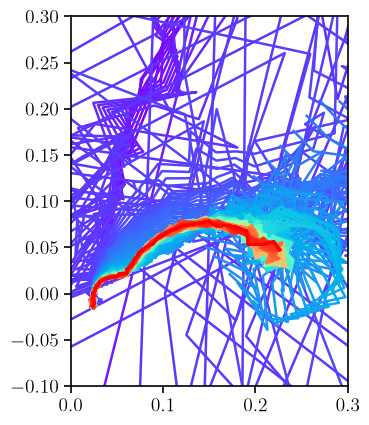

In [26]:
time_start = 0.1
time_end = 30.1
points = 301

specta_all = []
Times = np.linspace(time_start,time_end,points)
colors = we.get_colors(len(Times))

spectra_all = []
E = 1.46
plot = True
files = [r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\TRPEIS__1,46V_OCV180s_closed_cell2_PEIS.csv",
         r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\TRPEIS__1,46V_OCV120s_closed_cell2_PEIS.csv",
         r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\TRPEIS__1,46V_OCV90s_closed_cell2_PEIS.csv",
         r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\TRPEIS__1,46V_OCV60s_closed_cell3_PEIS.csv",
         r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\TRPEIS__1,46V_OCV45s_closed_cell2_PEIS.csv",
         r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\TRPEIS__1,46V_OCV30s_closed_cell2_PEIS.csv"
        ]
files = [r"C:\Users\Herman\OneDrive - Univerzita Karlova\trgeis_at_0,1A_for_30s_and_270s_OCV_GEIS.txt"]
for file in files:
    spectra = []
    with open(file,'r', encoding='latin1') as f:
        df = pd.read_csv(f,skiprows = 0,delimiter = r'\t')
    
    for j,t in enumerate(Times):
        Re_query = []
        Im_query= []
        I_query = []
        freq_query = []
        t_query = np.full(len(np.unique(df['freq/Hz'])[1:]), t)
        # t_query = np.full(len(np.unique(df['Freq'])[1:]), t)
        # for f in np.unique(df['Freq'])[1:]:
        for f in np.unique(df['freq/Hz'])[1:]:
            Re = df.loc[(df["freq/Hz"] == f), 'Re(Z)/Ohm'].values
            Im = -df.loc[(df["freq/Hz"] == f), '-Im(Z)/Ohm'].values
            time = df.loc[(df["freq/Hz"] == f), 'time/s'].values
            I = df.loc[(df["freq/Hz"] == f), 'I/mA'].values
            freq = df.loc[(df["freq/Hz"] == f), 'freq/Hz'].values

            # Re = df.loc[(df["Freq"] == f), 'Re'].values
            # Im = -df.loc[(df["Freq"] == f), 'Im'].values
            # time = df.loc[(df["Freq"] == f), 't'].values
            # I = df.loc[(df["Freq"] == f), 'I'].values
            # freq = df.loc[(df["Freq"] == f), 'Freq'].values
            Re_query.append(np.interp(t, time-time[0], Re))
            Im_query.append(-np.interp(t, time-time[0], Im))
            I_query.append(np.interp(t, time-time[0], I))
            freq_query.append(np.interp(t, time-time[0], freq))
        spectra.append([freq_query,np.array(Re_query) - 1j*np.array(Im_query),np.array(I_query),E])      
        if plot:
            plt.plot(Re_query,np.array(Im_query),'-',c=colors[j])
    spectra_all.append(spectra)
    if plot: 
        plt.xlim(0,0.3)
        plt.ylim(-0.1,0.3)
        plt.gca().set_aspect('equal')
        plt.show()

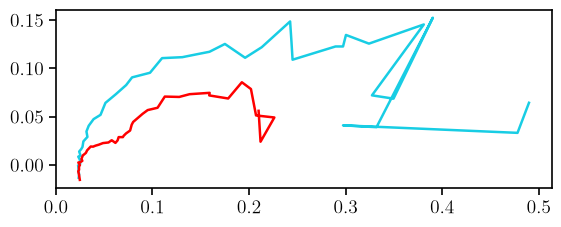

In [25]:
for index,spectrum in enumerate(spectra_all[0]):
    if index == 15 or index == 50:
        plt.plot(spectrum[1].real,-spectrum[1].imag, c = colors[index])
    plt.gca().set_aspect('equal')
plt.show()

In [ ]:
for index,spectrum in enumerate(spectra_all[0]):
    if index == 15 or index == 50:
        plt.plot(spectrum[1].real,-spectrum[1].imag, c = colors[index])
    plt.gca().set_aspect('equal')
plt.show()

In [77]:
cir = 'R0-L0-p(R1,CPE1)-p(R2,CPE2)'
init = [0.02,1e-8,0.01,0.01,0.8,0.5,0.1,0.8]
bounds = ([0.001,1e-8,0.00001,0.0001,0.6,0.0001,0.001,0.6],[0.5,1e-5,1,1,1,100,1,1])

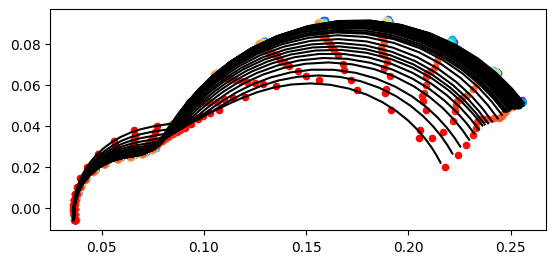

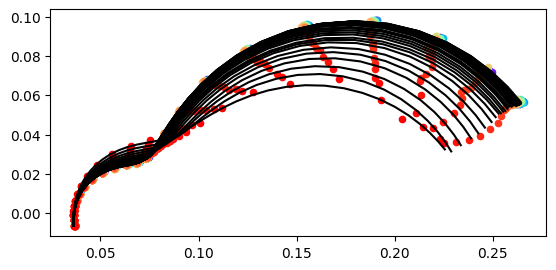

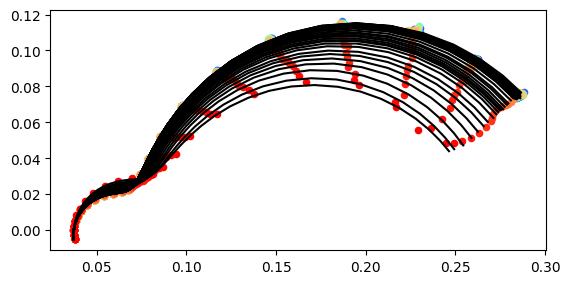

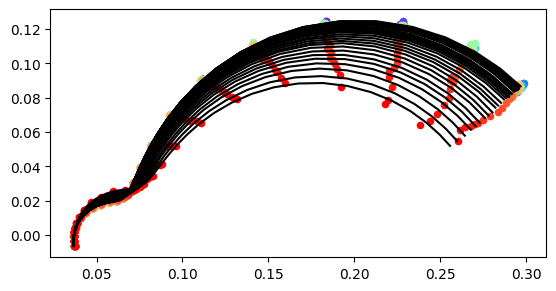

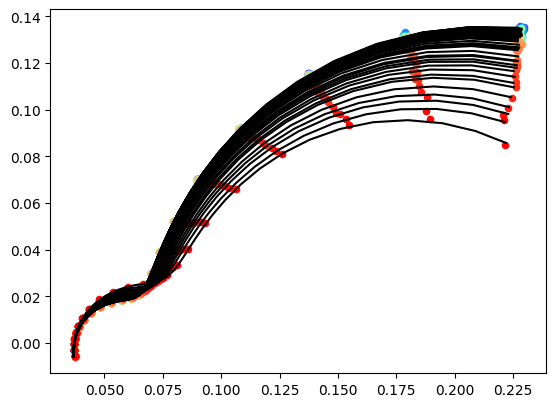

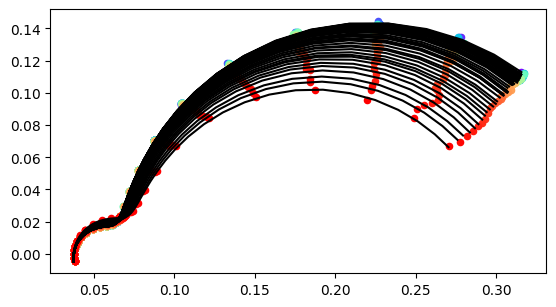

In [78]:
params_all = []
for spectra in spectra_all:
    
    params = loop.spectra_fitting(list(reversed(spectra))[:-3],bounds = bounds, init = init,freq_lims = [1,100000])
    params_all.append(params)


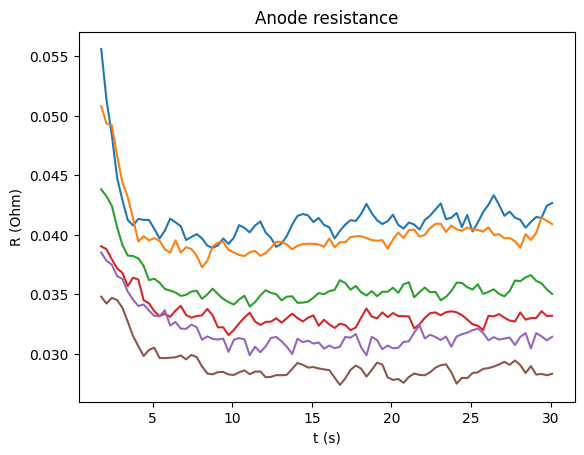

In [80]:
for params in params_all:
    plt.plot(Times[5:],list(reversed(params[:,2]))[1:])
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Anode resistance')
    # plt.legend()


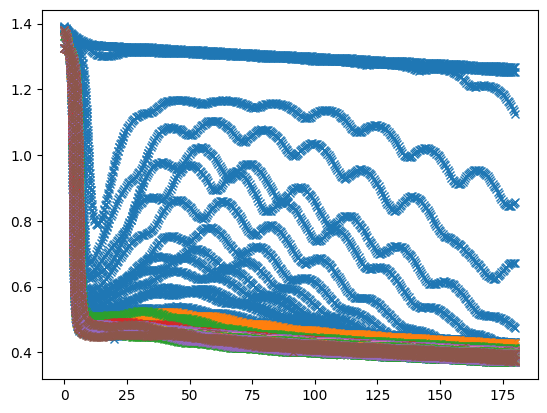

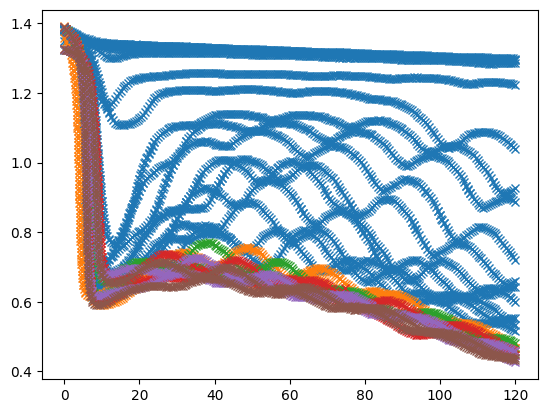

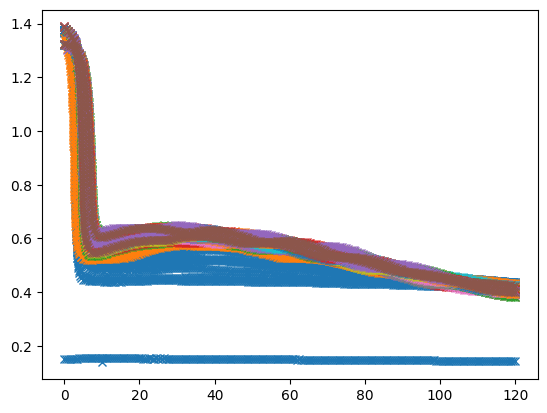

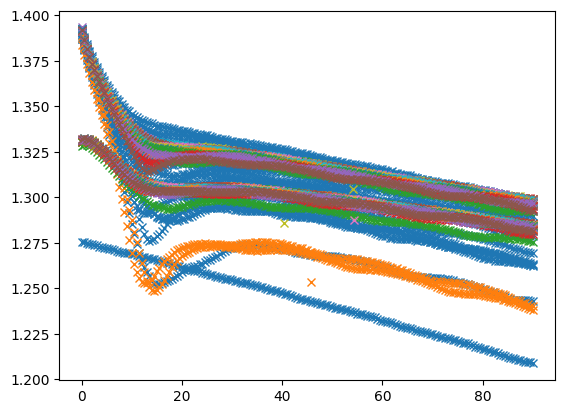

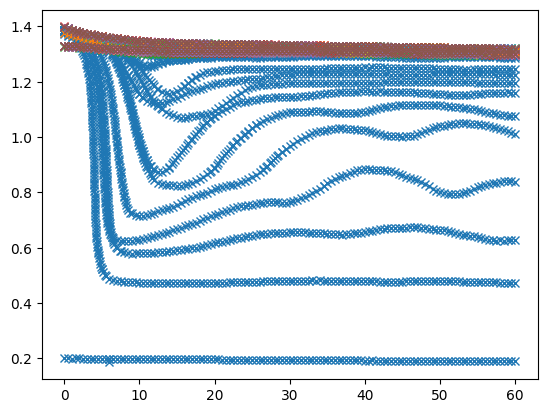

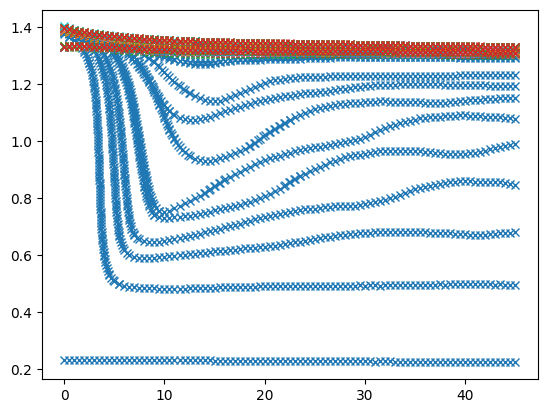

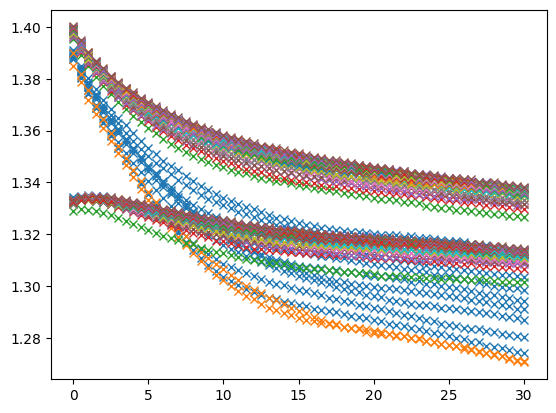

In [83]:
time_start = 0.1
time_end = 30.1
points = 91

specta_all = []
Times = np.linspace(time_start,time_end,points)
colors = we.get_colors(len(Times))

spectra_all = []
E = 1.46
plot = True
files = [r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\TRPEIS__1,46V_OCV180s_closed_cell2_OCV.csv",
         r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\TRPEIS__1,46V_OCV120s_closed_cell4_OCV.csv",
          r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\TRPEIS__1,46V_OCV120s_closed_cell2_OCV.csv",
         r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\TRPEIS__1,46V_OCV90s_closed_cell2_OCV.csv",
         r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\TRPEIS__1,46V_OCV60s_closed_cell3_OCV.csv",
         r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\TRPEIS__1,46V_OCV45s_closed_cell2_OCV.csv",
         r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\TRPEIS__1,46V_OCV30s_closed_cell2_OCV.csv"
        ]

for file in files:
    spectra = []
    with open(file,'r', encoding='latin1') as f:
        df = pd.read_csv(f,skiprows = 0,delimiter = ',')
    for l in np.unique(df['Tech'])[0:]:
        # E = df['<Ewe>/V']
        # time = df['time/s']
        E = df.loc[(df["Tech"] == l), '<Ewe>/V'].values
        time = df.loc[(df["Tech"] == l), 'time/s'].values
        plt.plot(time,E,'x')
    plt.show()
    # for j,t in enumerate(Times):
    #     Re_query = []
    #     Im_query= []
    #     I_query = []
    #     freq_query = []
    #     t_query = np.full(len(np.unique(df['freq/Hz'])[1:]), t)
    #     # t_query = np.full(len(np.unique(df['Freq'])[1:]), t)
    #     # for f in np.unique(df['Freq'])[1:]:
    #     for f in np.unique(df['freq/Hz'])[1:]:
    #         Re = df.loc[(df["freq/Hz"] == f), 'Re(Z)/Ohm'].values
    #         Im = -df.loc[(df["freq/Hz"] == f), '-Im(Z)/Ohm'].values
    #         time = df.loc[(df["freq/Hz"] == f), 'time/s'].values
    #         I = df.loc[(df["freq/Hz"] == f), '<I>/mA'].values
    #         freq = df.loc[(df["freq/Hz"] == f), 'freq/Hz'].values

    #         # Re = df.loc[(df["Freq"] == f), 'Re'].values
    #         # Im = -df.loc[(df["Freq"] == f), 'Im'].values
    #         # time = df.loc[(df["Freq"] == f), 't'].values
    #         # I = df.loc[(df["Freq"] == f), 'I'].values
    #         # freq = df.loc[(df["Freq"] == f), 'Freq'].values
    #         Re_query.append(np.interp(t, time-time[0], Re))
    #         Im_query.append(-np.interp(t, time-time[0], Im))
    #         I_query.append(np.interp(t, time-time[0], I))
    #         freq_query.append(np.interp(t, time-time[0], freq))
    #     spectra.append([freq_query,np.array(Re_query) - 1j*np.array(Im_query),np.array(I_query),E])      
    #     if plot:
    #         plt.plot(Re_query,np.array(Im_query),'-',c=colors[j])
    # spectra_all.append(spectra)
    # if plot: 
    #     plt.gca().set_aspect('equal')
    #     plt.show()

In [142]:
Is = []
for spectra in spectra_all:
    I = []
    for spectrum in spectra:
        i = np.mean(spectrum[2])
        I.append(i)
    Is.append(I)


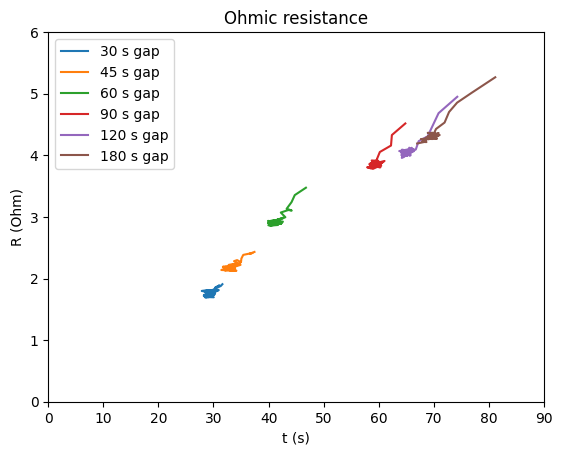

In [143]:
for params,label,I in zip(params_all,times,Is):
    # Cc = (params[:,2]*params[:,3]**(1-params[:,4]))**(1/params[:,4])
    plt.plot(I[5:],1/np.array(list(reversed(params[:,5])))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Ohmic resistance')
    plt.xlim(0,90)
    plt.ylim(0,6)
    plt.legend()

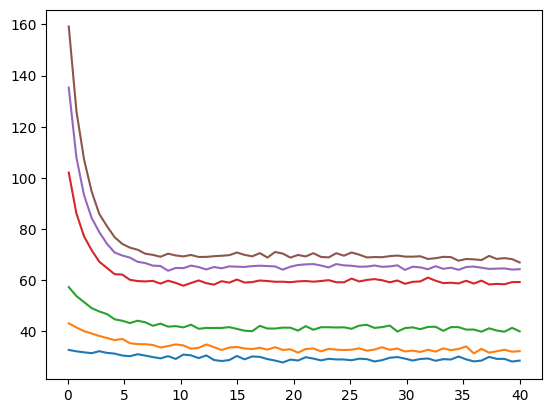

In [144]:
for I in Is:
    plt.plot(Times,I)

# 372 1,46 V open cell

In [44]:
times = [30,45,60,90,120,180]
# times = [300]
files = []
for time in times:
    files.append( glob(os.path.join(r'\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\1,46 V different time gaps open cell/','*'+str(time)+'s*'+'*PEIS_C01.mpt')))
    # print(files)
    # "\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\new\L_02_Loopeis 1,40V_2_PEIS from 65kHz to 10kHz_03_PEIS_C01.mpt"

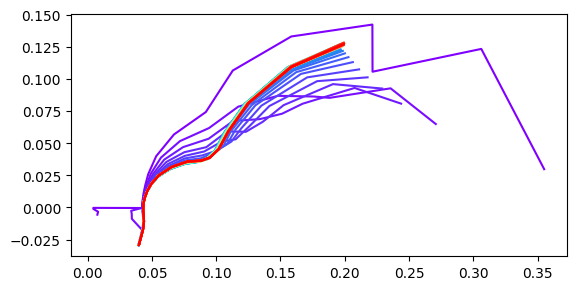

30 s done


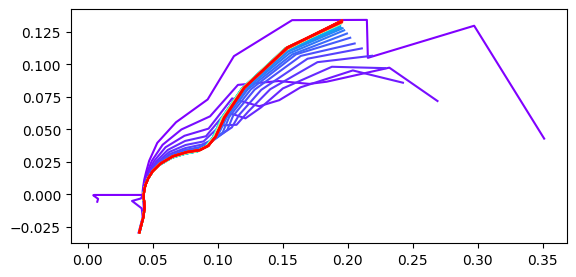

45 s done


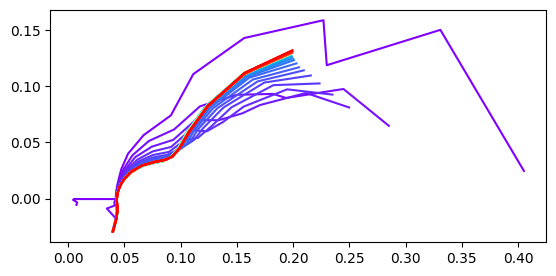

60 s done


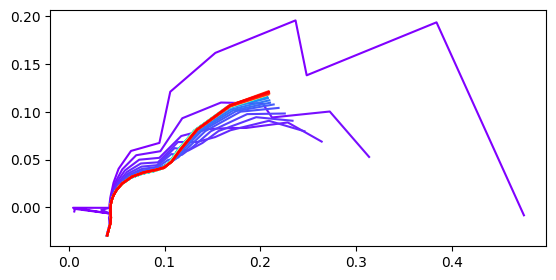

90 s done


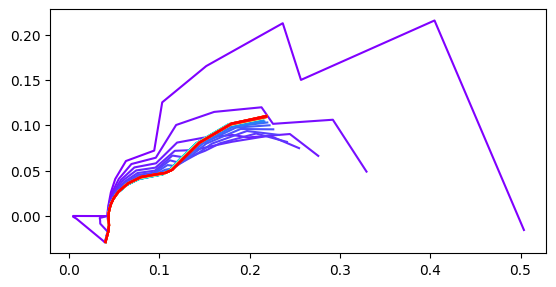

120 s done


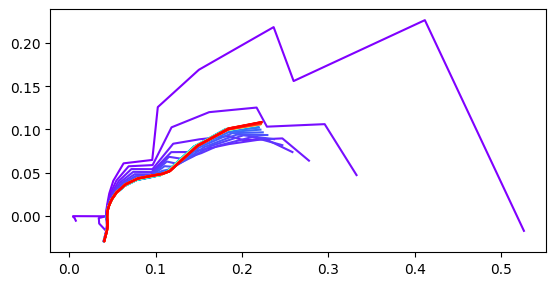

180 s done


In [46]:
spectra_all = []

time_start = 0.1
time_end = 40
points = 60
Times = np.linspace(time_start,time_end,points)
for time,file in zip(times,files):
    spectra= loop.spectra_calculation(list(reversed(file)),1.48, time_start,time_end,points, plot = True,control = 'Ref')
    
    spectra_all.append(spectra)
    print(str(time)+' s done')

In [47]:
cir = 'R0-L0-p(R1,CPE1)-p(R2,CPE2)'
init = [0.02,1e-8,0.01,0.01,0.8,0.5,0.1,0.8]
bounds = ([0.001,1e-8,0.00001,0.0001,0.6,0.0001,0.001,0.6],[0.5,1e-5,1,1,1,100,1,1])

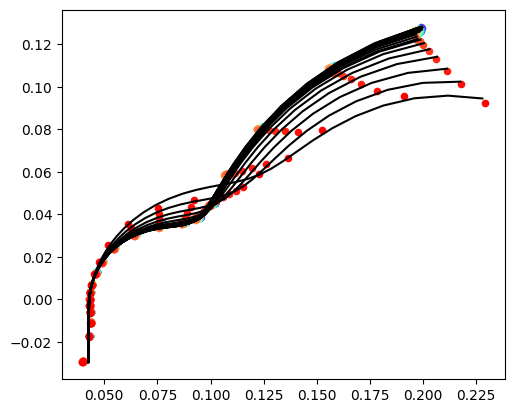

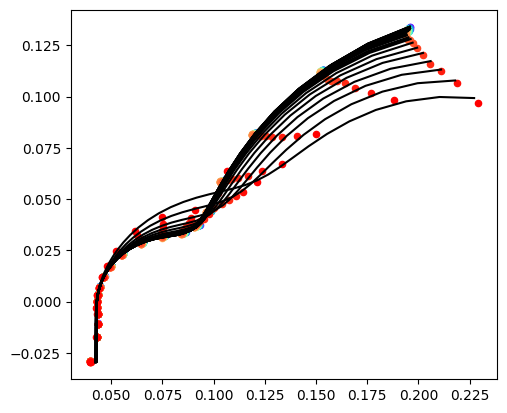

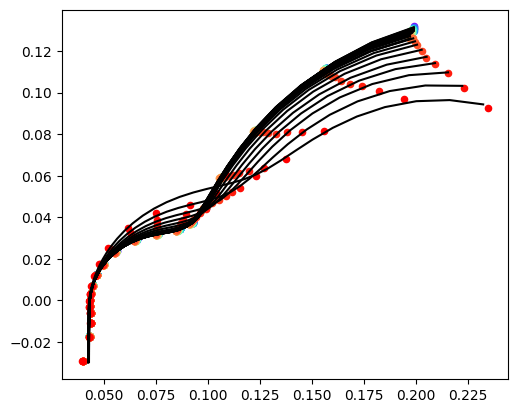

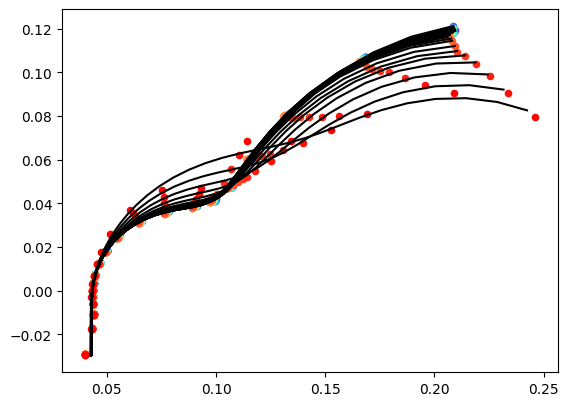

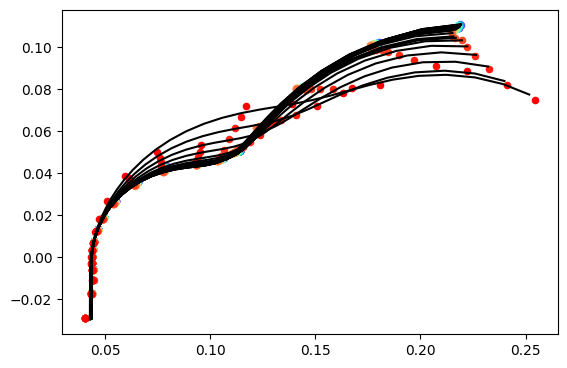

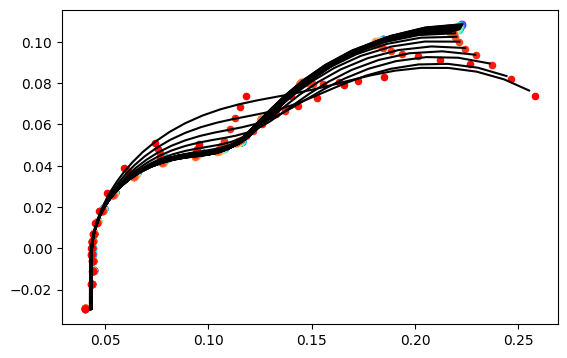

In [48]:
params_all = []
for spectra in spectra_all:
    
    params = loop.spectra_fitting(list(reversed(spectra))[:-3],bounds = bounds, init = init,freq_lims = [1,100000])
    params_all.append(params)


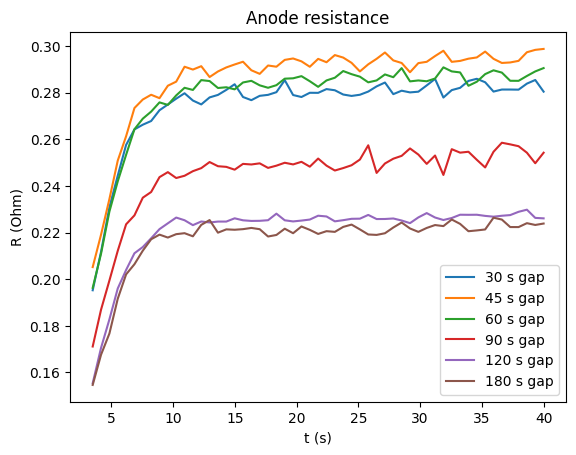

In [49]:
for params,label in zip(params_all,times):
    plt.plot(Times[5:],list(reversed(params[:,5]))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Anode resistance')
    plt.legend()


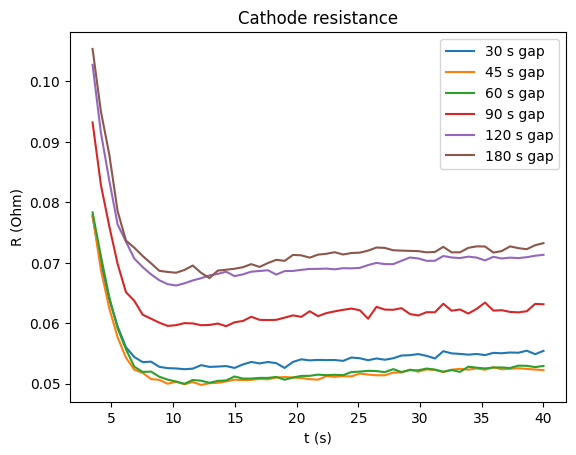

In [50]:
for params,label in zip(params_all,times):
    plt.plot(Times[5:],list(reversed(params[:,2]))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Cathode resistance')
    plt.legend()


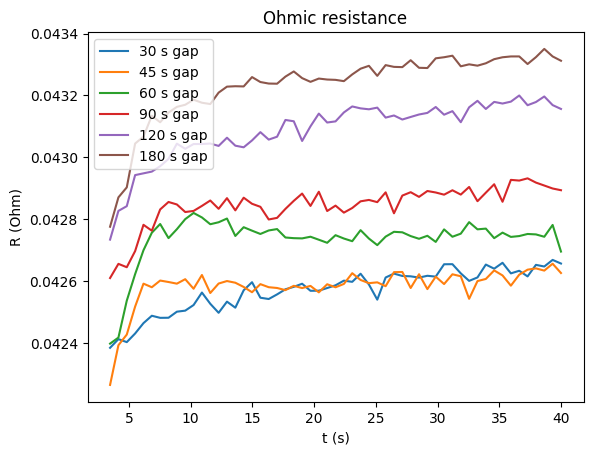

In [51]:
for params,label in zip(params_all,times):
    plt.plot(Times[5:],list(reversed(params[:,0]))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Ohmic resistance')
    plt.legend()


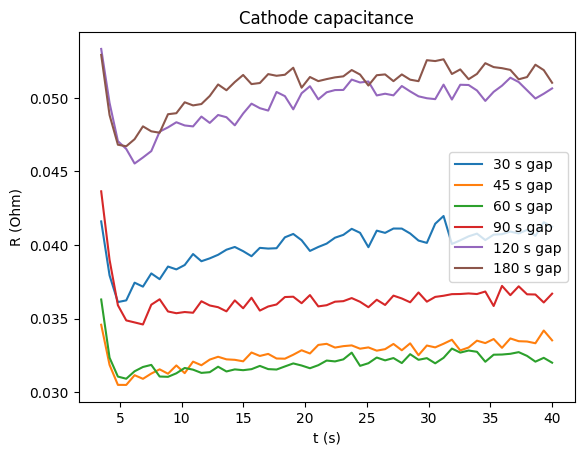

In [52]:
for params,label in zip(params_all,times):
    Cc = (params[:,2]*params[:,3]**(1-params[:,4]))**(1/params[:,4])
    plt.plot(Times[5:],list(reversed(Cc))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Cathode capacitance')
    plt.legend()

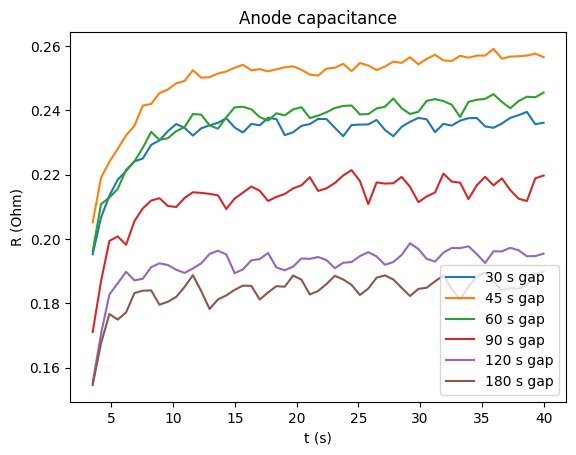

In [53]:
for params,label in zip(params_all,times):
    Ca = (params[:,5]*params[:,6]**(1-params[:,7]))**(1/params[:,7])
    plt.plot(Times[5:],list(reversed(Ca))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Anode capacitance')
    plt.legend()

In [54]:
Is = []
for spectra in spectra_all:
    I = []
    for spectrum in spectra:
        i = np.mean(spectrum[2])
        I.append(i)
    Is.append(I)


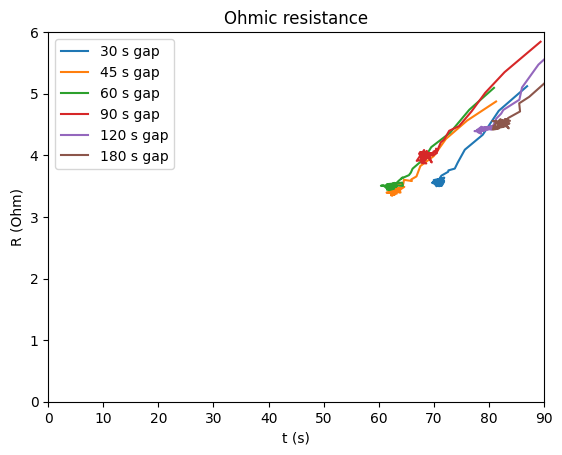

In [55]:
for params,label,I in zip(params_all,times,Is):
    # Cc = (params[:,2]*params[:,3]**(1-params[:,4]))**(1/params[:,4])
    plt.plot(I[5:],1/np.array(list(reversed(params[:,5])))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Ohmic resistance')
    plt.xlim(0,90)
    plt.ylim(0,6)
    plt.legend()

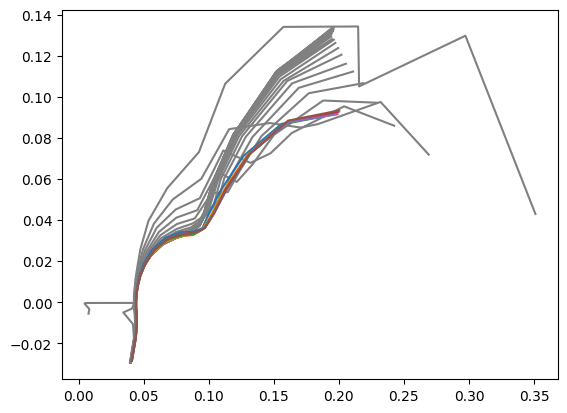

In [77]:

for spectrum in spectra_all[1]:
    # print(spectrum[1])
    Z = np.array(spectrum[1])
    plt.plot(Z.real,-Z.imag,c = 'grey')

df = we.read_file(r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\1,46 V different time gaps open cell\normal_PEIS_1,46V_45s_09_PEIS_C01.mpt")
unique_vals = np.unique(df['cycle number'])
for val in unique_vals:
    f,Z = weis.freq_and_Z(df,val,freq_lims = [10,7e4],control = 'Ewe')
    plt.plot(Z.real,-Z.imag)
    

# 372 1,46 V nitrogen

In [39]:
# times = [30,45,60,90,180]
times = [180]
files = []
for time in times:
    files.append(natsorted(glob(os.path.join(r'C:\Users\Herman\Desktop\WE\Loopeis\1,46V 180 s kbio measured/','*PEIS*'+str(time)+'s*')))[1:])
    # files = 
    print(natsorted(files))
    # "\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\new\L_02_Loopeis 1,40V_2_PEIS from 65kHz to 10kHz_03_PEIS_C01.mpt"

[['C:\\Users\\Herman\\Desktop\\WE\\Loopeis\\1,46V 180 s kbio measured\\output_PEIS_1,46V_180s_1.csv', 'C:\\Users\\Herman\\Desktop\\WE\\Loopeis\\1,46V 180 s kbio measured\\output_PEIS_1,46V_180s_2.csv', 'C:\\Users\\Herman\\Desktop\\WE\\Loopeis\\1,46V 180 s kbio measured\\output_PEIS_1,46V_180s_3.csv', 'C:\\Users\\Herman\\Desktop\\WE\\Loopeis\\1,46V 180 s kbio measured\\output_PEIS_1,46V_180s_4.csv', 'C:\\Users\\Herman\\Desktop\\WE\\Loopeis\\1,46V 180 s kbio measured\\output_PEIS_1,46V_180s_5.csv', 'C:\\Users\\Herman\\Desktop\\WE\\Loopeis\\1,46V 180 s kbio measured\\output_PEIS_1,46V_180s_6.csv', 'C:\\Users\\Herman\\Desktop\\WE\\Loopeis\\1,46V 180 s kbio measured\\output_PEIS_1,46V_180s_7.csv', 'C:\\Users\\Herman\\Desktop\\WE\\Loopeis\\1,46V 180 s kbio measured\\output_PEIS_1,46V_180s_8.csv', 'C:\\Users\\Herman\\Desktop\\WE\\Loopeis\\1,46V 180 s kbio measured\\output_PEIS_1,46V_180s_9.csv', 'C:\\Users\\Herman\\Desktop\\WE\\Loopeis\\1,46V 180 s kbio measured\\output_PEIS_1,46V_180s_10.csv

In [2]:
def spectra_calculation_csv(files,E, time_start = 0.5, time_end = 30, points = 60, plot = True, control = 'Ref'):
    Times = np.linspace(time_start,time_end,points)
    colors = we.get_colors(len(Times))
    spectra = []
    
    for j,t in enumerate(Times):
        Re_query = []
        Im_query= []
        I_query = []
        freq_query = []
        
        t_query = np.full(len(files), t)
        for i,file in enumerate(files):
    
            # skip_rows = 1
            with open(file,'r', encoding='latin1') as f:
                df = pd.read_csv(f,skiprows = 0,delimiter = ',')
            # print(df)
            if control == 'Ref':
                Re = df['Re']
                Im = df['Im']
            elif control == 'CE':
                Re = df['Re(Zwe-ce)/Ohm']
                Im = df['-Im(Zwe-ce)/Ohm']
            freq = df['Freq']
            time = df['t']
            # print(file)
            # print(time[0])
            I = df['I']
            Re_query.append(np.interp(t, time-time[0], Re))
            Im_query.append(np.interp(t, time-time[0], Im))
            I_query.append(np.interp(t, time-time[0], I))
            freq_query.append(np.interp(t, time-time[0], freq))

        spectra.append([freq_query,np.array(Re_query) - 1j*np.array(Im_query),np.array(I_query),E])
            
        if plot:
            plt.plot(Re_query,Im_query,'-',c=colors[j])
        
    if plot: 
        plt.gca().set_aspect('equal')
        plt.show()
    return spectra

6054


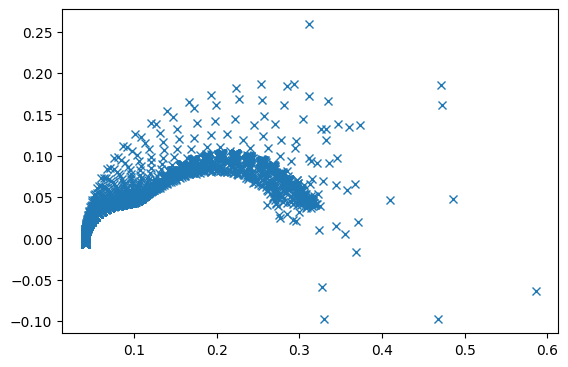

In [60]:
control = 'Ref'
file = r"C:\Users\Herman\Desktop\WE\Loopeis\1,46V 180 s kbio measured\output_PEIS_1,46V_180s_dense.csv"
# file = r"C:\Users\Herman\Desktop\WE\Loopeis\1,46V 180 s kbio measured\output_PEIS_1,46V_180s_dense.csv"
# file = r"C:\Users\Herman\Desktop\WE\Loopeis\output_PEIS_1,42V_30s.csv"
# file = r"C:\Users\Herman\Desktop\WE\Loopeis\outputAEM_PEIS_1,6V_60s.csv"

with open(file,'r', encoding='latin1') as f:
    df = pd.read_csv(f,skiprows = 0,delimiter = ',')
# print(df)
if control == 'Ref':
    Re = df['Re']
    Im = df['Im']
elif control == 'CE':
    Re = df['Re(Zwe-ce)/Ohm']
    Im = df['-Im(Zwe-ce)/Ohm']
freq = df['Freq']
time = df['t']
# print(file)
# print(time[0])
print(len(Re))
I = df['I']
plt.plot(Re,-Im,'x')

plt.gca().set_aspect('equal')
plt.show()


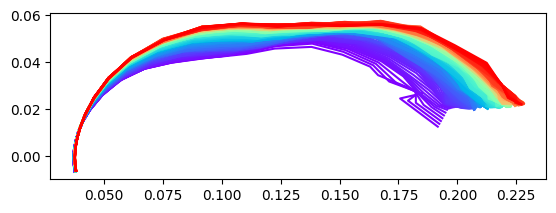

In [37]:
time_start = 0.1
time_end = 30.1
points = 301

specta_all = []
Times = np.linspace(time_start,time_end,points)
colors = we.get_colors(len(Times))

spectra_all = []
E = 1.46
plot = True

files = [r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\TRPEIS__1,46V_OCV180s_N2_3_PEIS.csv"]

# files = [r"\\ELECTROLYZER\PEM-WE_measurements\2026\AEM-WE\404_VI_VI NiAl high CapR, piperion, plain, RDC 1028, 1h\404_VI_VI NiAl high CapR, piperion, plain, RDC 1028, 1hTRPEIS__1,6V_OCV150s_closed_cell_PEIS.csv"]
# file = r"C:\Users\Herman\Desktop\WE\Loopeis\output_PEIS_1,42V_30s.csv"
for file in files:
    spectra = []
    with open(file,'r', encoding='latin1') as f:
        df = pd.read_csv(f,skiprows = 0,delimiter = ',')
    
    for j,t in enumerate(Times):
        Re_query = []
        Im_query= []
        I_query = []
        freq_query = []
        
        t_query = np.full(len(np.unique(df['freq/Hz'])[1:]), t)
        # t_query = np.full(len(np.unique(df['Freq'])[1:]), t)
        # for f in np.unique(df['Freq'])[1:]:
        for f in np.unique(df['freq/Hz'])[1:]:
            Re = df.loc[(df["freq/Hz"] == f), 'Re(Z)/Ohm'].values
            Im = -df.loc[(df["freq/Hz"] == f), '-Im(Z)/Ohm'].values
            time = df.loc[(df["freq/Hz"] == f), 'time/s'].values
            I = df.loc[(df["freq/Hz"] == f), '<I>/mA'].values
            freq = df.loc[(df["freq/Hz"] == f), 'freq/Hz'].values


            # Re = df.loc[(df["Freq"] == f), 'Re'].values
            # Im = -df.loc[(df["Freq"] == f), 'Im'].values
            # time = df.loc[(df["Freq"] == f), 't'].values
            # I = df.loc[(df["Freq"] == f), 'I'].values
            # freq = df.loc[(df["Freq"] == f), 'Freq'].values

            
            Re_query.append(np.interp(t, time-time[0], Re))
            Im_query.append(-np.interp(t, time-time[0], Im))
            I_query.append(np.interp(t, time-time[0], I))
            freq_query.append(np.interp(t, time-time[0], freq))
    
        spectra.append([freq_query,np.array(Re_query) - 1j*np.array(Im_query),np.array(I_query),E])
            
        if plot:
            plt.plot(Re_query,np.array(Im_query),'-',c=colors[j])
    spectra_all.append(spectra)
    if plot: 
        plt.gca().set_aspect('equal')
        plt.show()


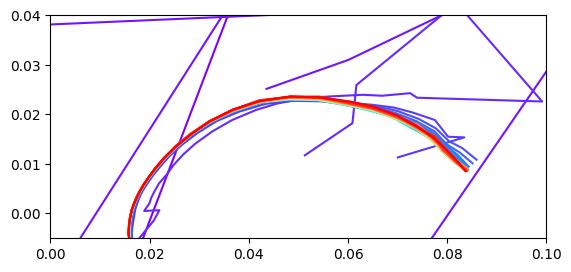

In [11]:
for spectra in spectra_all:
    colors = we.get_colors(len(spectra))
    for spectrum,color in zip(spectra,colors):
        plt.plot(spectrum[1].real,-spectrum[1].imag,c=color)
    plt.xlim(0.00,0.1)
    plt.ylim(-0.005,0.04)
    plt.gca().set_aspect('equal')
    plt.show()

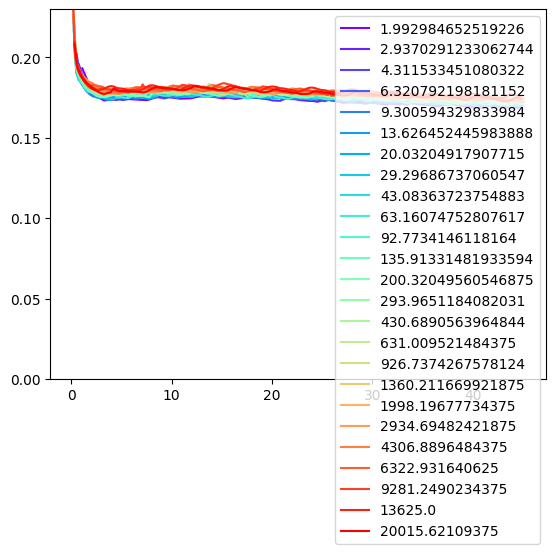

In [27]:

file1 = r"C:\Users\Herman\Desktop\WE\Loopeis\1,46V 180 s kbio measured\output_PEIS_1,46V_180s_26.csv"
file2 = r"C:\Users\Herman\Desktop\WE\Loopeis\1,46V 180 s kbio measured\output_PEIS_1,46V_180s_dense.csv"
# files = [file1,file2]


for file in files:
    with open(file,'r', encoding='latin1') as f:
        df = pd.read_csv(f,skiprows = 0,delimiter = ',')
    
    colors = we.get_colors(len(np.unique(df['freq/Hz'])))
    for f,color in zip(np.unique(df['freq/Hz']),colors):
    
        time = df.loc[(df["freq/Hz"] == f), 'time/s'].values
        I = df.loc[(df["freq/Hz"] == f), '<I>/mA'].values
    
            
        if plot:
            plt.plot(time-min(time)+(time[1]-time[0]),I,'-',c=color,label = f)
        
        # if plot: 
            # plt.gca().set_aspect('equal')
            # plt.ylim(0.15,0.2)
plt.ylim(0,0.23)
plt.legend()
plt.show()


In [10]:

times = ['H2','N2']
time_start = 0.1
time_end = 40
points = 60
Times = np.linspace(time_start,time_end,points)
for time,spectra in zip(times,spectra_all):
    spectra= loop.spectra_calculation(spectra,1.48, time_start,time_end,points, plot = True,control = 'Ref')
    
    spectra_all.append(spectra)
    print(str(time)+' s done')

TypeError: expected str, bytes or os.PathLike object, not list

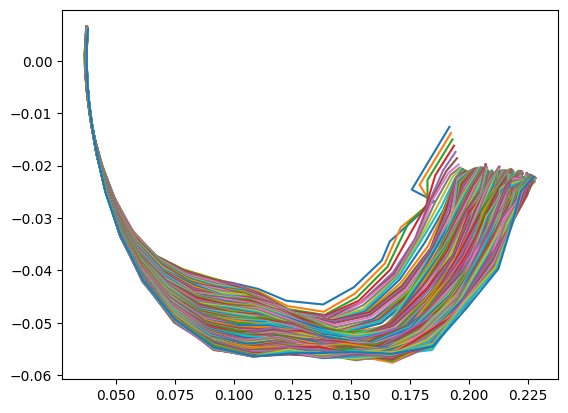

In [38]:
# params_all = []
# for spectra in spectra_all:
for t,spectrum in zip(Times,spectra_all[0]):
    plt.plot(spectrum[1].real,spectrum[1].imag)
    f = spectrum[0]
    Re = spectrum[1].real
    Im = spectrum[1].imag
    data = [f,Re,Im]
    data = np.array(data)
    t_str = str(round(t,4)).zfill(4)
    # print(t_str)
    np.savetxt(r'C:\Users\Herman\Desktop\WE\Loopeis\paper graphs\1,46 V 180 s gap N2 spectra/'+t_str+'.txt',data.T,delimiter = '\t')


In [34]:
cir = 'R0-L0-p(R1,CPE1)-p(R2,CPE2)'
init = [0.02,1e-8,0.01,0.01,0.8,0.5,0.1,0.8]
bounds = ([0.001,1e-8,0.00001,0.0001,0.6,0.0001,0.001,0.6],[0.5,1e-5,1,1,1,100,1,1])

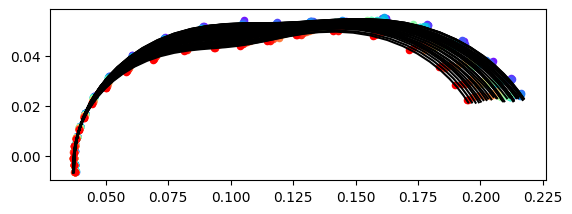

In [25]:
params_all = []
# for spectra in spectra_all:
for spectra in spectra_all:
    params = loop.spectra_fitting(list(reversed(spectra))[:-3],bounds = bounds, init = init,freq_lims = [0.5,100000])
    params_all.append(params)


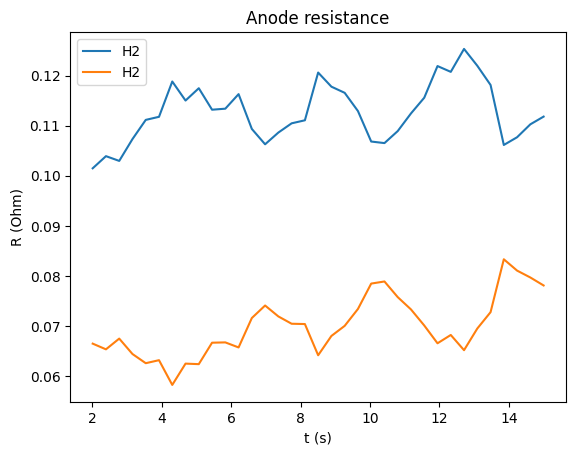

In [26]:
for params,label in zip(params_all,times):
    plt.plot(Times[5:],list(reversed(params[:,5]))[1:],label =label)
    plt.plot(Times[5:],list(reversed(params[:,2]))[1:],label = label)
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Anode resistance')
    
plt.legend()
# plt.ylim(0,0.15)


(180.0, 185.0)

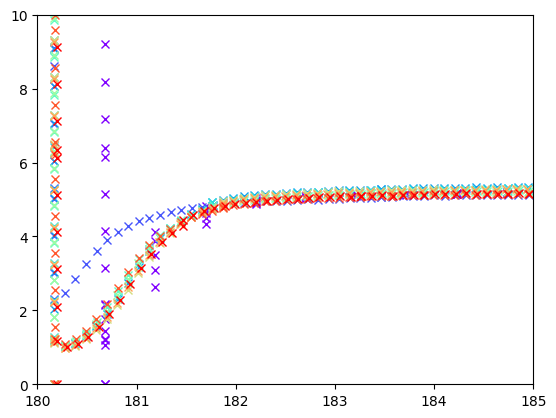

In [21]:
file = r"C:\Users\Herman\Desktop\WE\Loopeis\outputAEM_CA_1,9V_180s.csv"
data = np.loadtxt(file,skiprows = 1,delimiter = ',')
all_data = [[data[0,:]]]
for row in data:
    if row[0] < all_data[-1][-1][0]:
        all_data.append([])
    all_data[-1].append(row)
# print(all_data)    
colors = we.get_colors(len(all_data))
for dat,col in zip(all_data,colors):
    plt.plot(np.array(dat)[:,0],np.array(dat)[:,2],'x',c=col)
# plt.plot(data[:,0],data[:,2],'x')
plt.ylim(0,10)
plt.xlim(180,185)

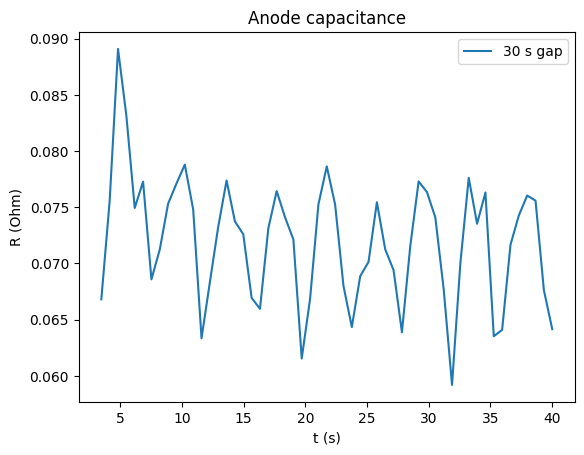

In [257]:
for params,label in zip(params_all,times):
    Ca = (params[:,5]*params[:,6]**(1-params[:,7]))**(1/params[:,7])
    plt.plot(Times[5:],list(reversed(Ca))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Anode capacitance')
    plt.legend()

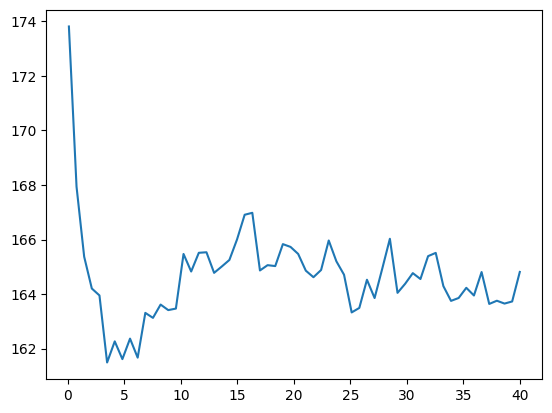

In [261]:
Is = []
for spectra in spectra_all:
    I = []
    for spectrum in spectra:
        i = np.mean(spectrum[2])
        I.append(i)
    Is.append(I)
plt.plot(Times,Is[0])

# 372 1,46 V hydrogen

In [108]:
times = [30,45,60,90,180]
# times = [300]
files = []
for time in times:
    files.append( glob(os.path.join(r'\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\1,46 V different time gaps H2/','*'+str(time)+'s*'+'*PEIS_C01.mpt')))
    # print(files)
    # "\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\new\L_02_Loopeis 1,40V_2_PEIS from 65kHz to 10kHz_03_PEIS_C01.mpt"

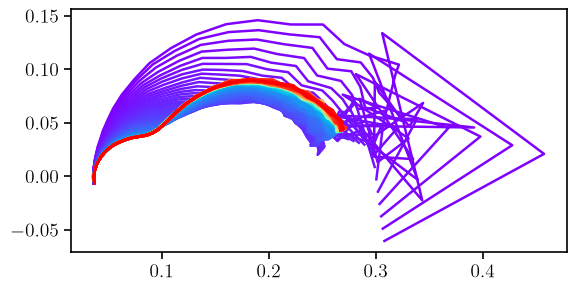

In [11]:
time_start = 0.1
time_end = 30.1
points = 301

specta_all = []
Times = np.linspace(time_start,time_end,points)
colors = we.get_colors(len(Times))

spectra_all = []
E = 1.46
plot = True

files = [#r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\TRPEIS__1,46V_OCV180s_H2_PEIS.csv",
         r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\TRPEIS__1,46V_OCV180s_open_cell5_PEIS.csv"
        #r"\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\TRPEIS__1,46V_OCV180s_N2_3_PEIS.csv"
        ]
# files = [r"\\ELECTROLYZER\PEM-WE_measurements\2026\AEM-WE\404_VI_VI NiAl high CapR, piperion, plain, RDC 1028, 1h\404_VI_VI NiAl high CapR, piperion, plain, RDC 1028, 1hTRPEIS__1,6V_OCV150s_closed_cell_PEIS.csv"]
# file = r"C:\Users\Herman\Desktop\WE\Loopeis\output_PEIS_1,42V_30s.csv"
for file in files:
    spectra = []
    with open(file,'r', encoding='latin1') as f:
        df = pd.read_csv(f,skiprows = 0,delimiter = ',')
    
    for j,t in enumerate(Times):
        Re_query = []
        Im_query= []
        I_query = []
        freq_query = []
        
        t_query = np.full(len(np.unique(df['freq/Hz'])[1:]), t)
        # t_query = np.full(len(np.unique(df['Freq'])[1:]), t)
        # for f in np.unique(df['Freq'])[1:]:
        for f in np.unique(df['freq/Hz'])[1:]:
            # print(f)
    
            # skip_rows = 1
    
            # print(df)
            # if control == 'Ref':
            Re = df.loc[(df["freq/Hz"] == f), 'Re(Z)/Ohm'].values
            Im = -df.loc[(df["freq/Hz"] == f), '-Im(Z)/Ohm'].values
            time = df.loc[(df["freq/Hz"] == f), 'time/s'].values
            I = df.loc[(df["freq/Hz"] == f), '<I>/mA'].values
            freq = df.loc[(df["freq/Hz"] == f), 'freq/Hz'].values


            # Re = df.loc[(df["Freq"] == f), 'Re'].values
            # Im = -df.loc[(df["Freq"] == f), 'Im'].values
            # time = df.loc[(df["Freq"] == f), 't'].values
            # I = df.loc[(df["Freq"] == f), 'I'].values
            # freq = df.loc[(df["Freq"] == f), 'Freq'].values

            
            Re_query.append(np.interp(t, time-time[0], Re))
            Im_query.append(-np.interp(t, time-time[0], Im))
            I_query.append(np.interp(t, time-time[0], I))
            freq_query.append(np.interp(t, time-time[0], freq))
    
        spectra.append([freq_query,np.array(Re_query) - 1j*np.array(Im_query),np.array(I_query),E])
            
        if plot:
            plt.plot(Re_query,np.array(Im_query),'-',c=colors[j])
    spectra_all.append(spectra)
    if plot: 
        plt.gca().set_aspect('equal')
        plt.show()

In [12]:
for t,spectrum in zip(Times,spectra_all[0]):
    Re = spectrum[1].real
    Im = spectrum[1].imag
    f = spectrum[0]
    # t_str = str(round(t,4)).zfill(4)
    data = [f,Re,Im]
    data = np.array(data)
    t_str = str(round(t,4)).zfill(4)
    np.savetxt(r'C:\Users\Herman\OneDrive - Univerzita Karlova\TRPEIS paper\paper graphs\1,46 V open cell different gaps\180/spectra_export_test'+t_str+'.txt',data.T,delimiter = '\t')

In [110]:
cir = 'R0-L0-p(R1,CPE1)-p(R2,CPE2)'
init = [0.02,1e-8,0.01,0.01,0.8,0.5,0.1,0.8]
bounds = ([0.001,1e-8,0.00001,0.0001,0.6,0.0001,0.001,0.6],[0.5,1e-5,1,1,1,100,1,1])

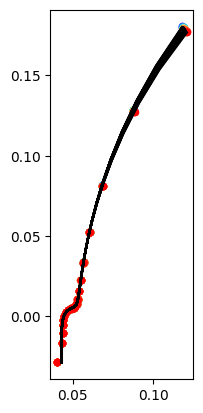

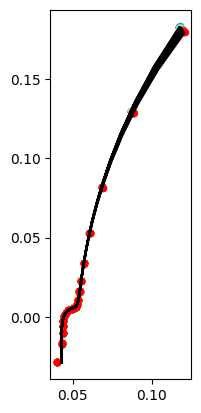

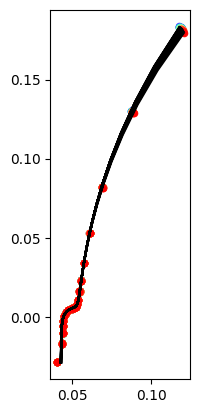

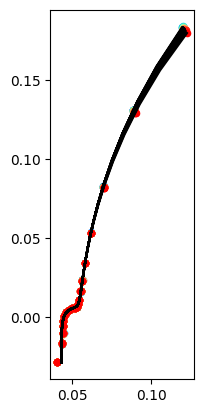

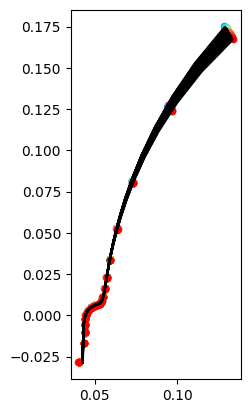

In [111]:
params_all = []
for spectra in spectra_all:
    
    params = loop.spectra_fitting(list(reversed(spectra))[:-3],bounds = bounds, init = init,freq_lims = [1,100000])
    params_all.append(params)


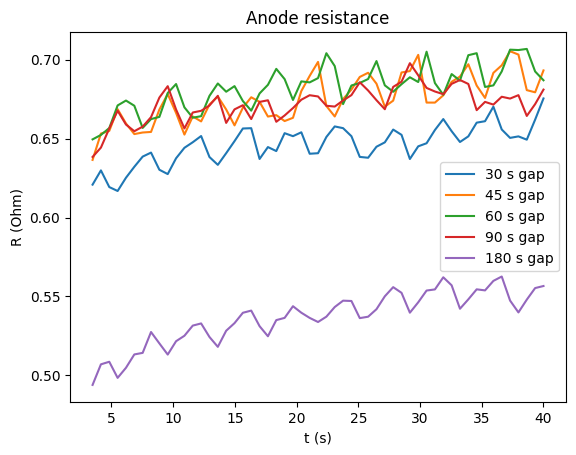

In [113]:
for params,label in zip(params_all,times):
    plt.plot(Times[5:],list(reversed(params[:,5]))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Anode resistance')
    plt.legend()


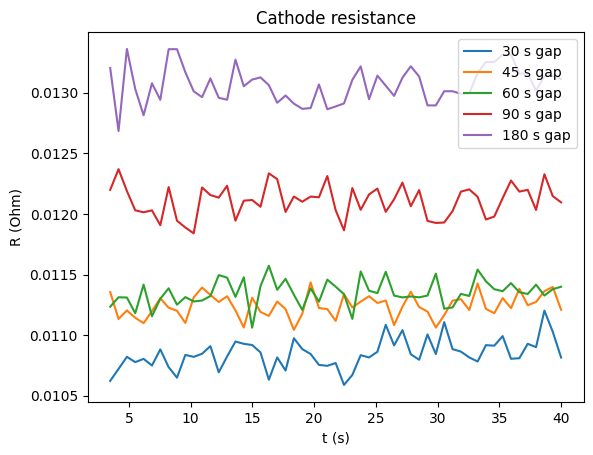

In [107]:
for params,label in zip(params_all,times):
    plt.plot(Times[5:],list(reversed(params[:,2]))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Cathode resistance')
    plt.legend()


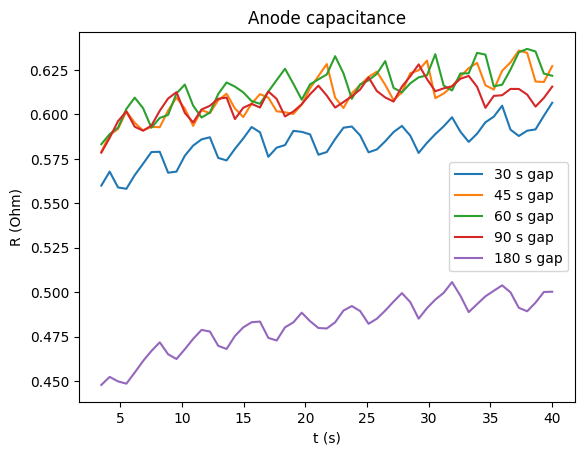

In [114]:
for params,label in zip(params_all,times):
    Ca = (params[:,5]*params[:,6]**(1-params[:,7]))**(1/params[:,7])
    plt.plot(Times[5:],list(reversed(Ca))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Anode capacitance')
    plt.legend()

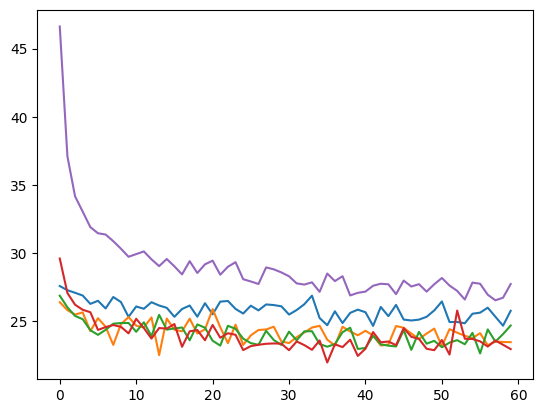

In [116]:
Is = []
for spectra in spectra_all:
    I = []
    for spectrum in spectra:
        i = np.mean(spectrum[2])
        I.append(i)
    Is.append(I)
    plt.plot(I)

# 372 1,46 V open cell with normal spectra

In [124]:
times = [30,45,60,90,120,180]
# times = [300]
files = []
for time in times:
    files.append( glob(os.path.join(r'\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\1,46 V different time gaps open cell new/','*Loop*'+str(time)+'s*'+'*PEIS_C01.mpt')))
    # print(files)
    # "\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\new\L_02_Loopeis 1,40V_2_PEIS from 65kHz to 10kHz_03_PEIS_C01.mpt"

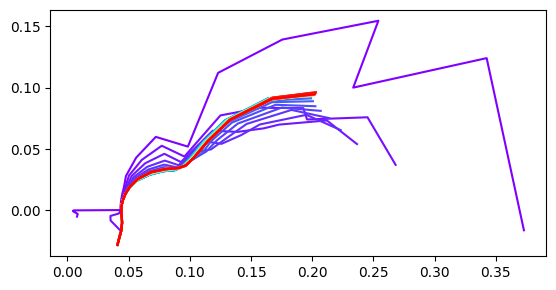

30 s done


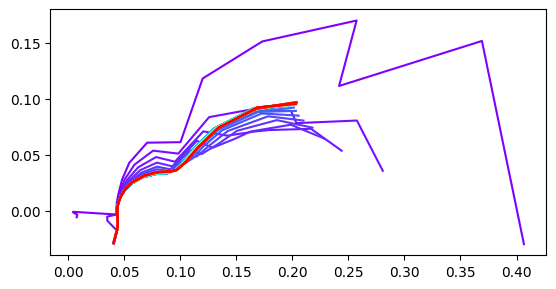

45 s done


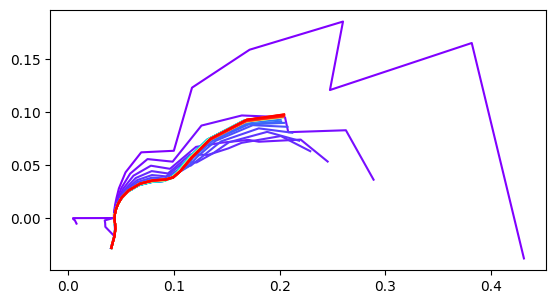

60 s done


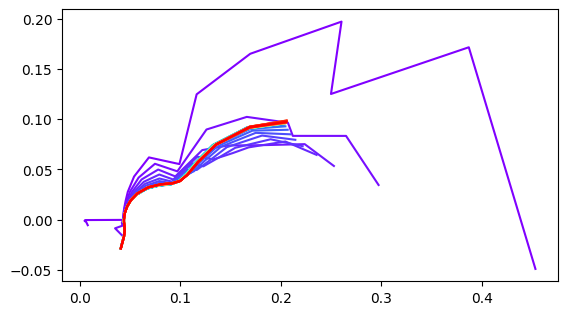

90 s done


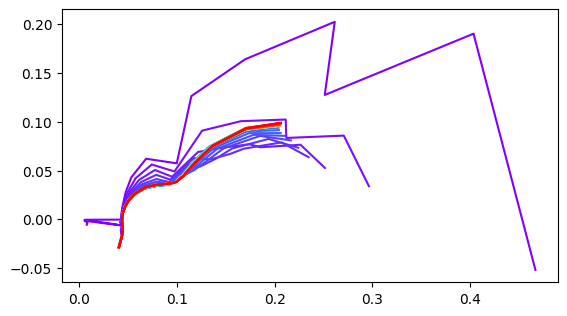

120 s done


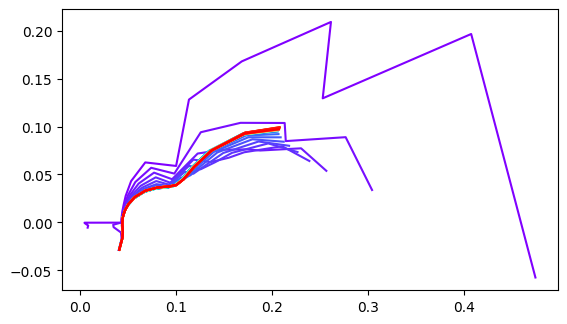

180 s done


In [125]:
spectra_all = []

time_start = 0.1
time_end = 40
points = 60
Times = np.linspace(time_start,time_end,points)
for time,file in zip(times,files):
    spectra= loop.spectra_calculation(list(reversed(file)),1.48, time_start,time_end,points, plot = True,control = 'Ref')
    
    spectra_all.append(spectra)
    print(str(time)+' s done')

In [97]:
cir = 'R0-L0-p(R1,CPE1)-p(R2,CPE2)'
init = [0.02,1e-8,0.01,0.01,0.8,0.5,0.1,0.8]
bounds = ([0.001,1e-8,0.00001,0.0001,0.6,0.0001,0.001,0.6],[0.5,1e-5,1,1,1,100,1,1])

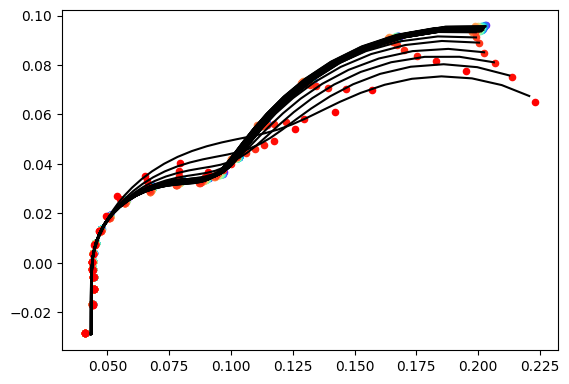

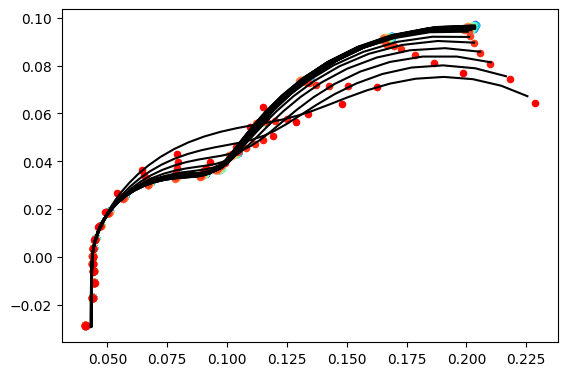

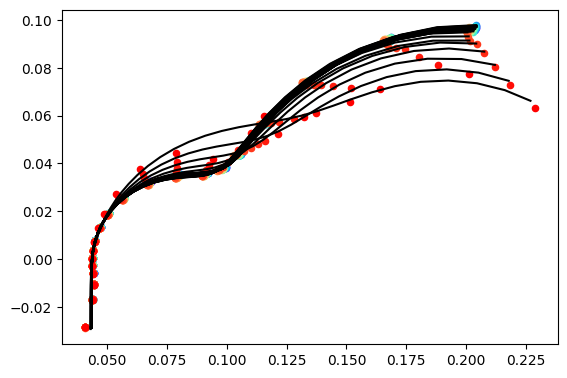

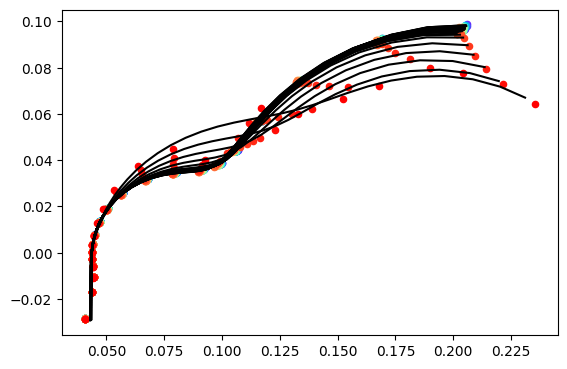

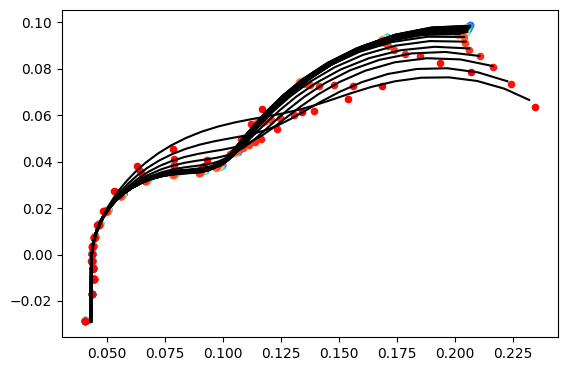

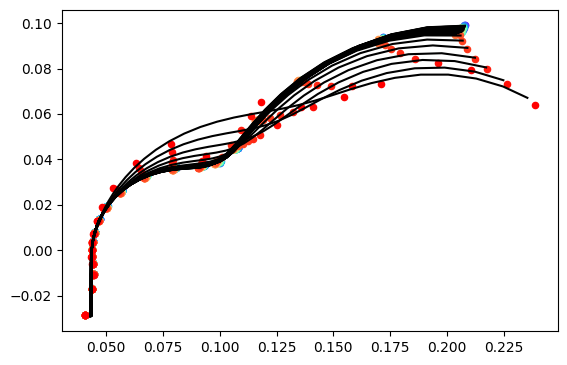

In [98]:
params_all = []
for spectra in spectra_all:
    
    params = loop.spectra_fitting(list(reversed(spectra))[:-3],bounds = bounds, init = init,freq_lims = [1,100000])
    params_all.append(params)


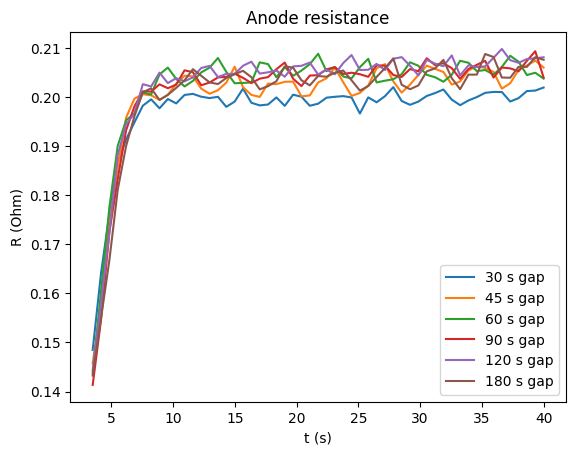

In [99]:
for params,label in zip(params_all,times):
    plt.plot(Times[5:],list(reversed(params[:,5]))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Anode resistance')
    plt.legend()


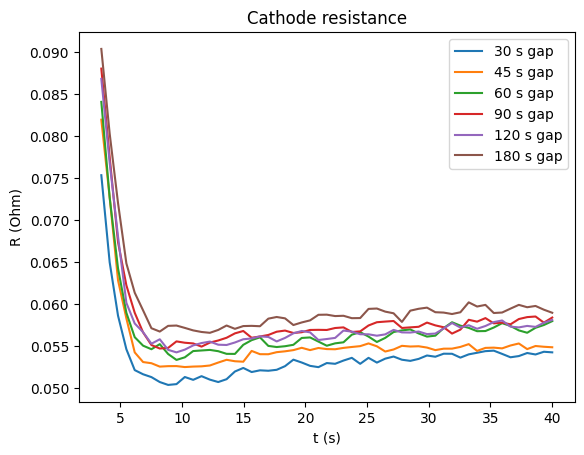

In [100]:
for params,label in zip(params_all,times):
    plt.plot(Times[5:],list(reversed(params[:,2]))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Cathode resistance')
    plt.legend()


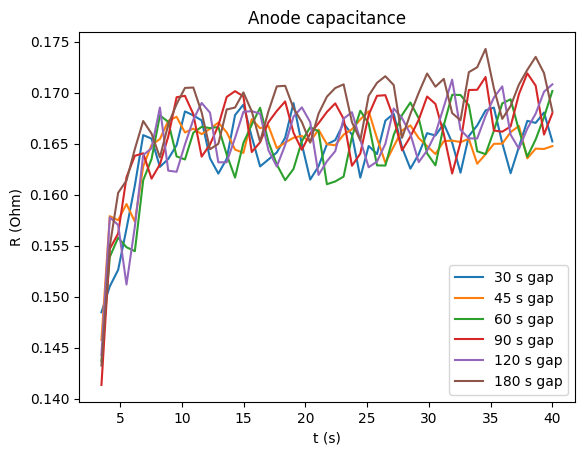

In [101]:
for params,label in zip(params_all,times):
    Ca = (params[:,5]*params[:,6]**(1-params[:,7]))**(1/params[:,7])
    plt.plot(Times[5:],list(reversed(Ca))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Anode capacitance')
    plt.legend()

['\\\\ELECTROLYZER\\PEM-WE_measurements\\2026\\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\\new station\\Loopeis new\\1,46 V different time gaps open cell new\\L_06_normal_PEIS_1,46V_30s_04_PEIS_C01.mpt', '\\\\ELECTROLYZER\\PEM-WE_measurements\\2026\\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\\new station\\Loopeis new\\1,46 V different time gaps open cell new\\L_06_normal_PEIS_1,46V_30s_09_PEIS_C01.mpt', '\\\\ELECTROLYZER\\PEM-WE_measurements\\2026\\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\\new station\\Loopeis new\\1,46 V different time gaps open cell new\\L_12_normal_PEIS_1,46V_45s_04_PEIS_C01.mpt', '\\\\ELECTROLYZER\\PEM-WE_measurements\\2026\\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\\new station\\Loopeis new\\1,46 V different time gaps open cell new\\L_12_normal_PEIS_1,46V_45s_09_PEIS_C01.mpt', '\\\\ELECTROLYZER\\PEM-WE_measurements\\2026\\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\\new station\\Loopeis new\\1,46 V different time gaps open

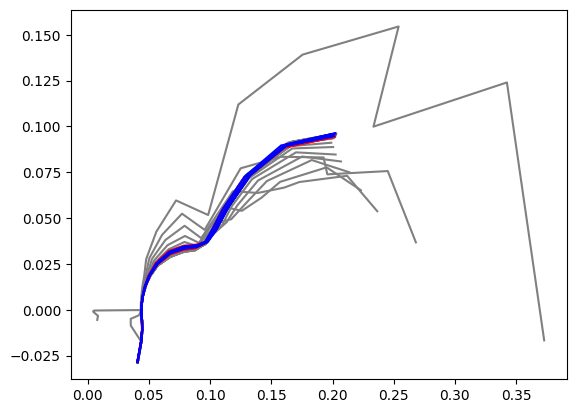

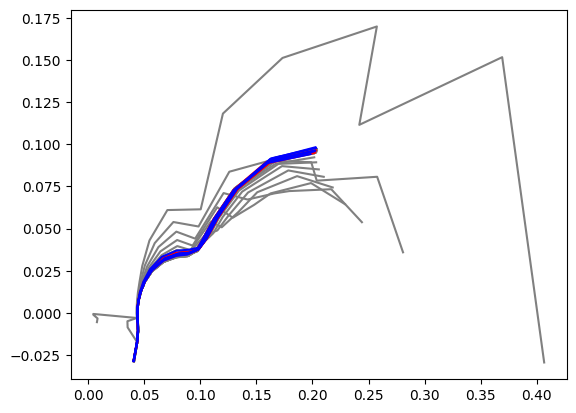

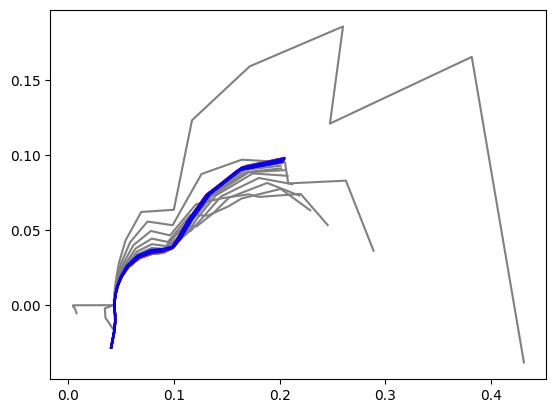

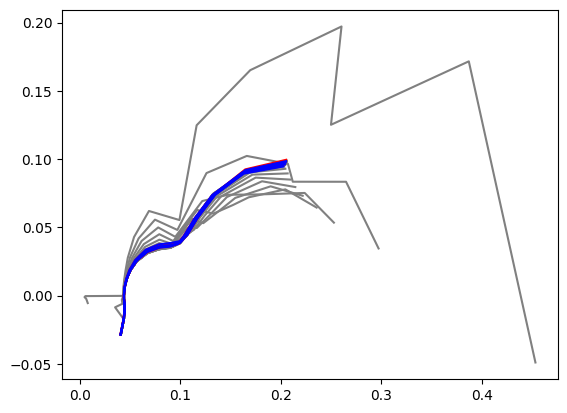

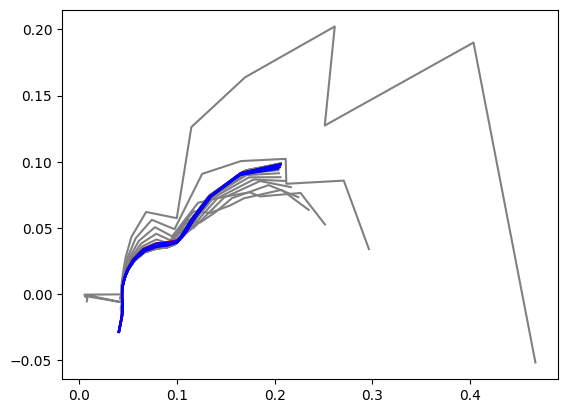

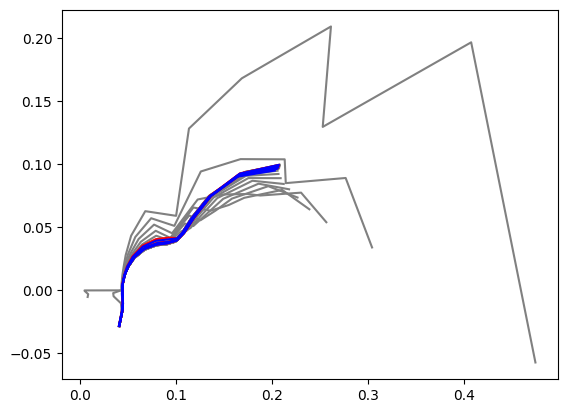

In [96]:
files_peis_normal  = ( glob(os.path.join(r'\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\1,46 V different time gaps open cell new/','*normal*'+'*s*'+'*PEIS_C01.mpt')))
print(files_peis_normal)   
for i,spectra in enumerate(spectra_all):
    # print(spectrum[1])
    for spectrum in spectra:
        Z = np.array(spectrum[1])
        plt.plot(Z.real,-Z.imag,c = 'grey')

   

    df = we.read_file(files_peis_normal[2*i])
    unique_vals = np.unique(df['cycle number'])
    for val in unique_vals:
        f,Z = weis.freq_and_Z(df,val,freq_lims = [10,7e4],control = 'Ewe')
        plt.plot(Z.real,-Z.imag,c='red')

    df = we.read_file(files_peis_normal[2*i+1])
    unique_vals = np.unique(df['cycle number'])
    for val in unique_vals:
        f,Z = weis.freq_and_Z(df,val,freq_lims = [10,7e4],control = 'Ewe')
        plt.plot(Z.real,-Z.imag,c='blue')
    plt.show()
    

['\\\\ELECTROLYZER\\PEM-WE_measurements\\2026\\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\\new station\\Loopeis new\\1,46 V different time gaps open cell new\\L_06_normal_PEIS_1,46V_30s_04_PEIS_C01.mpt', '\\\\ELECTROLYZER\\PEM-WE_measurements\\2026\\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\\new station\\Loopeis new\\1,46 V different time gaps open cell new\\L_06_normal_PEIS_1,46V_30s_09_PEIS_C01.mpt', '\\\\ELECTROLYZER\\PEM-WE_measurements\\2026\\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\\new station\\Loopeis new\\1,46 V different time gaps open cell new\\L_12_normal_PEIS_1,46V_45s_04_PEIS_C01.mpt', '\\\\ELECTROLYZER\\PEM-WE_measurements\\2026\\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\\new station\\Loopeis new\\1,46 V different time gaps open cell new\\L_12_normal_PEIS_1,46V_45s_09_PEIS_C01.mpt', '\\\\ELECTROLYZER\\PEM-WE_measurements\\2026\\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\\new station\\Loopeis new\\1,46 V different time gaps open

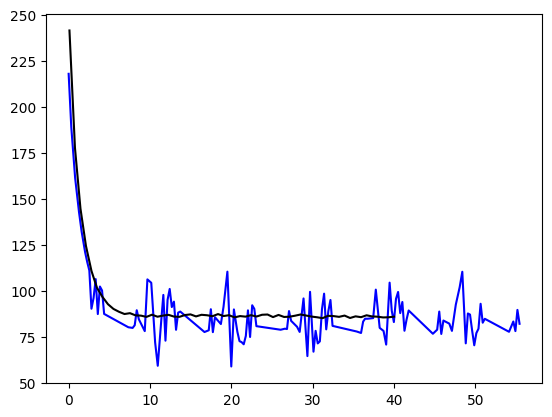

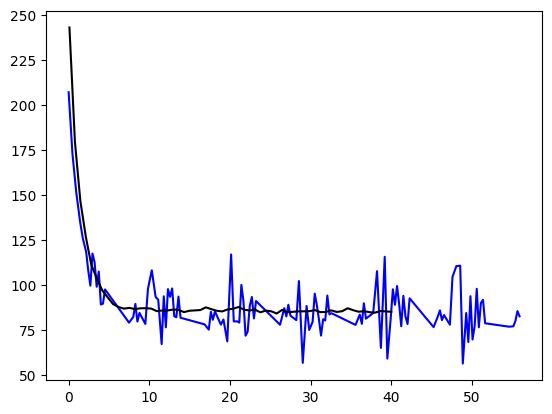

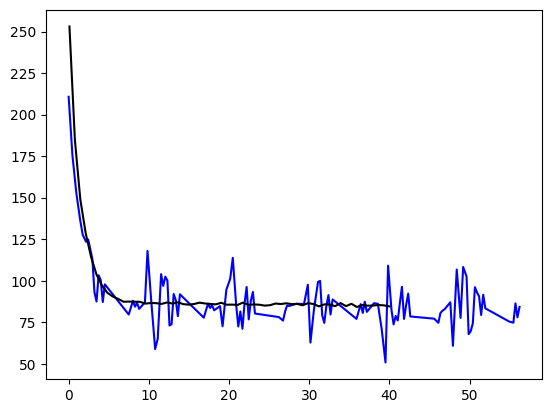

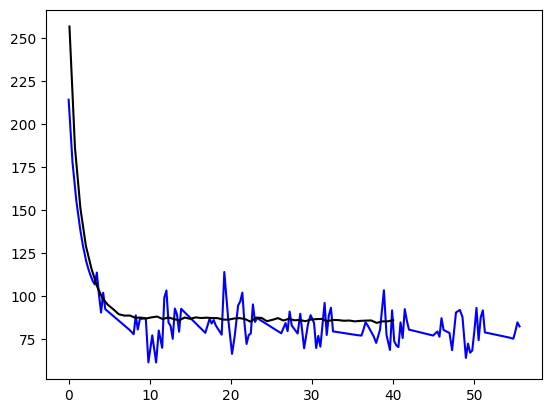

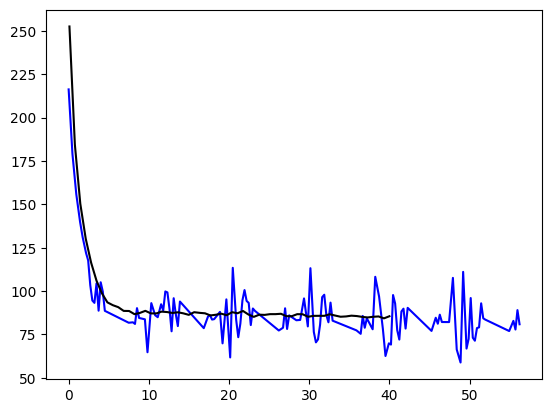

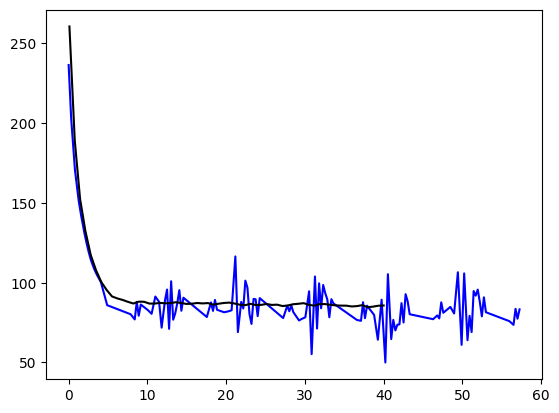

In [130]:
files_peis_normal  = ( glob(os.path.join(r'\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\1,46 V different time gaps open cell new/','*normal*'+'*s*'+'*PEIS_C01.mpt')))
print(files_peis_normal)   
for i,spectra in enumerate(spectra_all):
    # print(spectrum[1])


   

    df = we.read_file(files_peis_normal[2*i])
    time = df['time/s']
    I = df['<I>/mA']
    plt.plot(time-time[0],I,c='blue')


    I = []
    for spectrum in spectra:
        I.append(np.mean(spectrum[2]))
    plt.plot(Times,I,c = 'black')
    plt.show()
    # df = we.read_file(files_peis_normal[2*i+1])
    # unique_vals = np.unique(df['cycle number'])
    # for val in unique_vals:
    #     f,Z = weis.freq_and_Z(df,val,freq_lims = [10,7e4],control = 'Ewe')
    #     plt.plot(Z.real,-Z.imag,c='blue')
    # plt.show()
    

# 372 1,52 V closed cell


In [265]:
times = [30,60,120,180]
# times = [300]
files = []
for time in times:
    files.append( glob(os.path.join(r'\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\1,52 V different time gaps closed cell/','*'+str(time)+'s*'+'*PEIS_C01.mpt')))
    # print(files)
    # "\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\new\L_02_Loopeis 1,40V_2_PEIS from 65kHz to 10kHz_03_PEIS_C01.mpt"

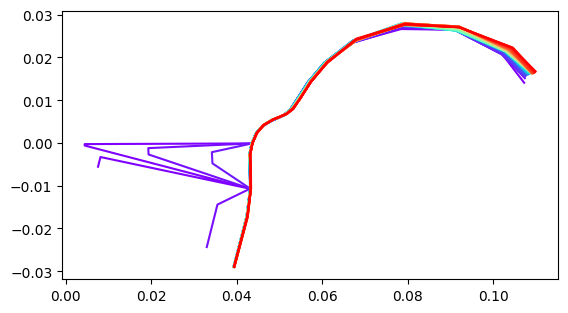

30 s done


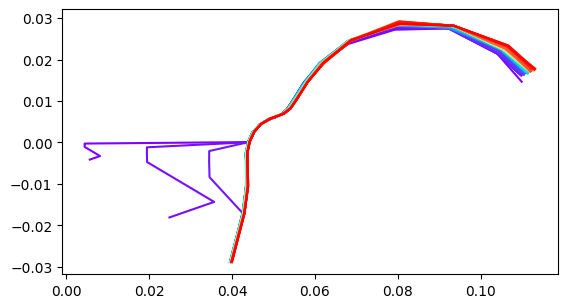

60 s done


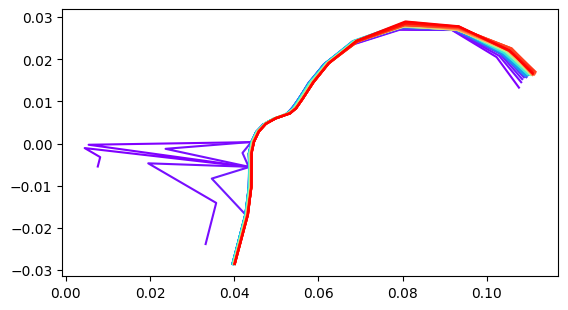

120 s done


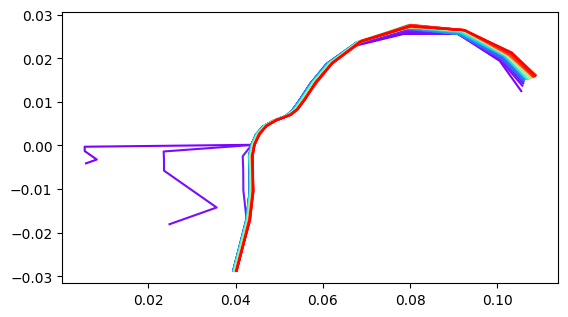

180 s done


In [266]:
spectra_all = []

time_start = 0.1
time_end = 20
points = 60
Times = np.linspace(time_start,time_end,points)
for time,file in zip(times,files):
    spectra= loop.spectra_calculation(list(reversed(file)),1.48, time_start,time_end,points, plot = True,control = 'Ref')
    
    spectra_all.append(spectra)
    print(str(time)+' s done')

In [267]:
cir = 'R0-L0-p(R1,CPE1)-p(R2,CPE2)'
init = [0.02,1e-8,0.01,0.01,0.8,0.5,0.1,0.8]
bounds = ([0.001,1e-8,0.00001,0.0001,0.6,0.0001,0.001,0.6],[0.5,1e-5,1,1,1,100,1,1])

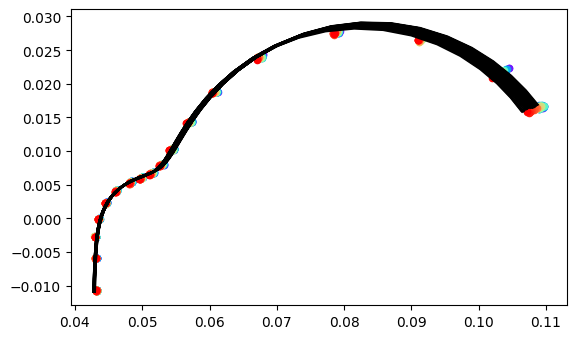

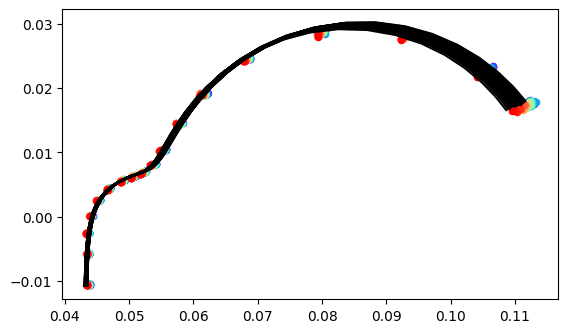

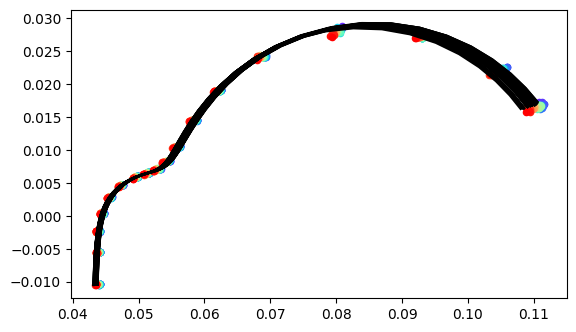

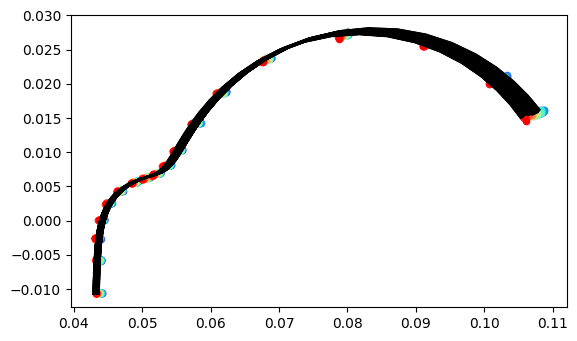

In [268]:
params_all = []
for spectra in spectra_all:
    
    params = loop.spectra_fitting(list(reversed(spectra))[:-3],bounds = bounds, init = init,freq_lims = [1,29000])
    params_all.append(params)


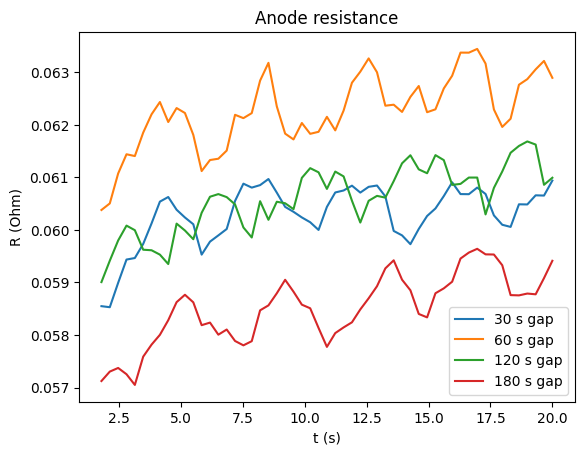

In [269]:
for params,label in zip(params_all,times):
    plt.plot(Times[5:],list(reversed(params[:,5]))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Anode resistance')
    plt.legend()


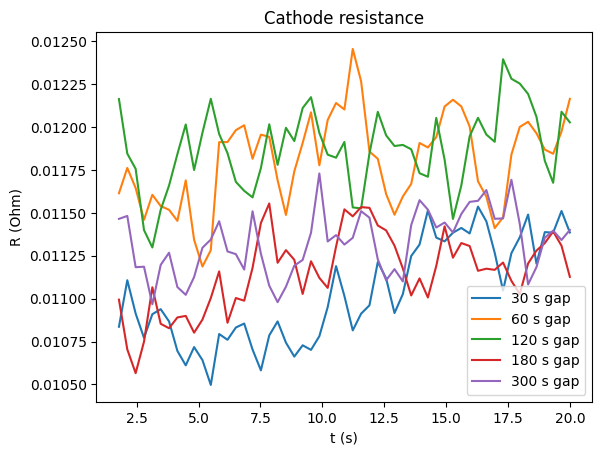

In [220]:
for params,label in zip(params_all,times):
    plt.plot(Times[5:],list(reversed(params[:,2]))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Cathode resistance')
    plt.legend()


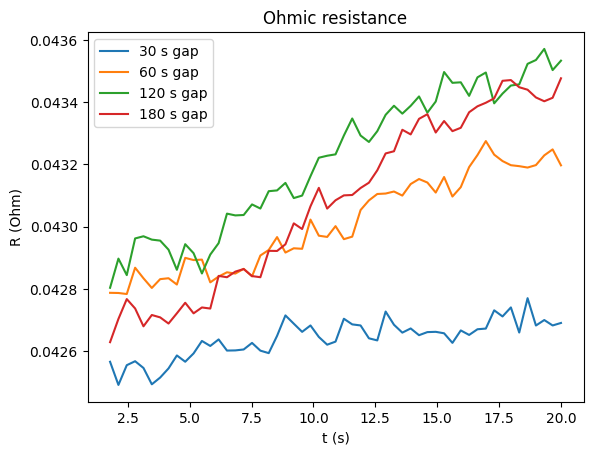

In [270]:
for params,label in zip(params_all,times):
    plt.plot(Times[5:],list(reversed(params[:,0]))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Ohmic resistance')
    plt.legend()


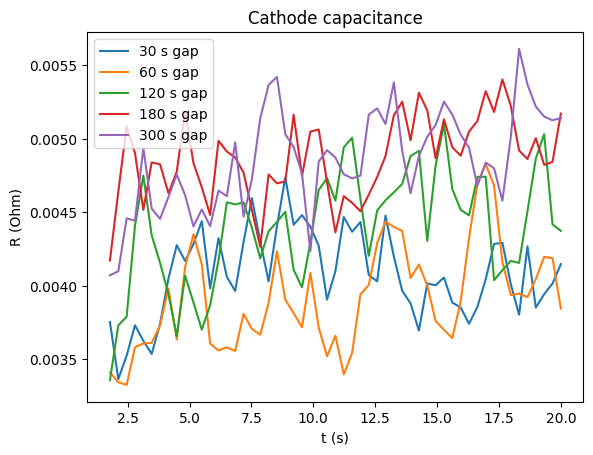

In [222]:
for params,label in zip(params_all,times):
    Cc = (params[:,2]*params[:,3]**(1-params[:,4]))**(1/params[:,4])
    plt.plot(Times[5:],list(reversed(Cc))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Cathode capacitance')
    plt.legend()

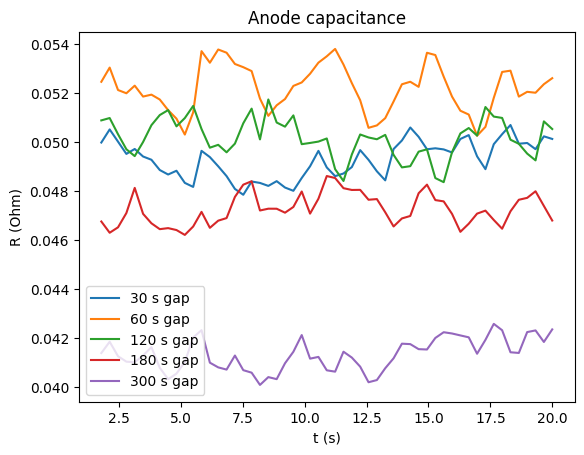

In [223]:
for params,label in zip(params_all,times):
    Ca = (params[:,5]*params[:,6]**(1-params[:,7]))**(1/params[:,7])
    plt.plot(Times[5:],list(reversed(Ca))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Anode capacitance')
    plt.legend()

In [271]:
Is = []
for spectra in spectra_all:
    I = []
    for spectrum in spectra:
        i = np.mean(spectrum[2])
        I.append(i)
    Is.append(I)


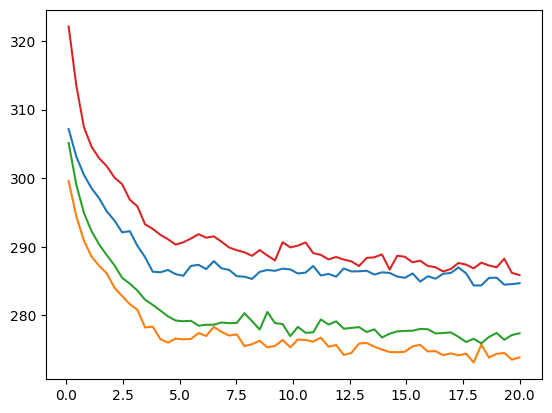

In [272]:
for I in Is:
    plt.plot(Times,I)

# 372 1,52 V open cell

In [199]:
times = [30,60,120,180,300]
# times = [300]
files = []
for time in times:
    files.append( glob(os.path.join(r'\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\1,52 V different time gaps open cell/','*'+str(time)+'s*'+'*PEIS_C01.mpt')))
    print(files)
    # "\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\new\L_02_Loopeis 1,40V_2_PEIS from 65kHz to 10kHz_03_PEIS_C01.mpt"

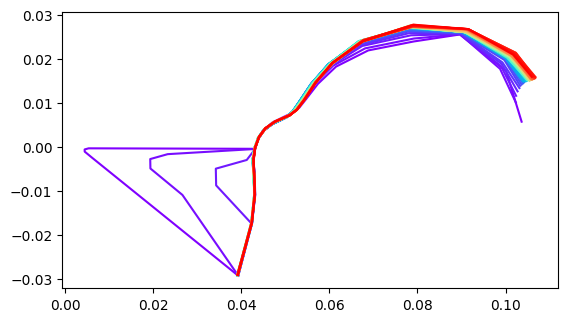

30 s done


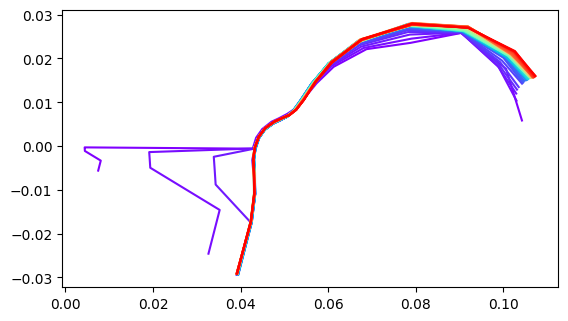

60 s done


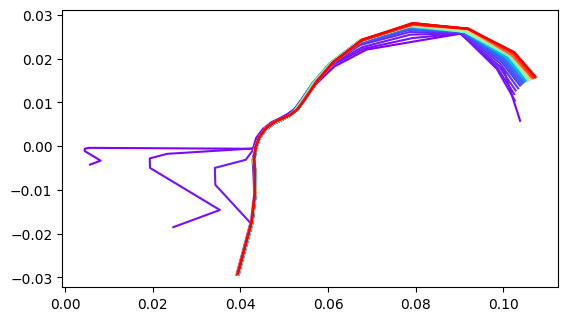

120 s done


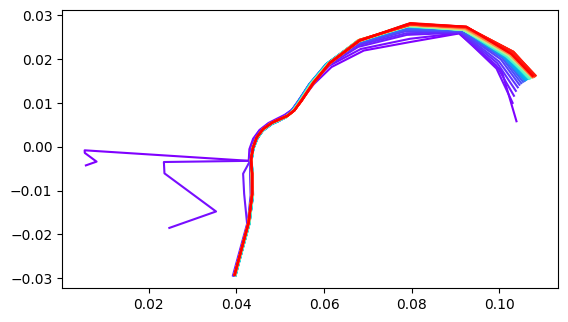

180 s done


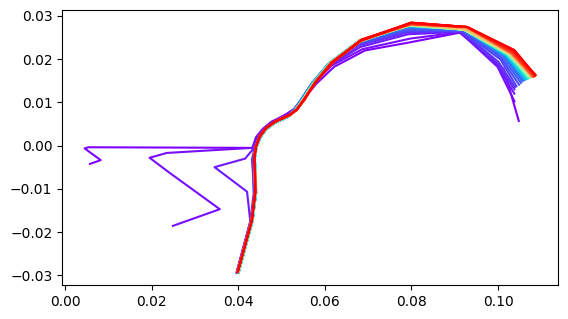

300 s done


In [200]:
spectra_all = []

time_start = 0.1
time_end = 20
points = 60
Times = np.linspace(time_start,time_end,points)
for time,file in zip(times,files):
    spectra= loop.spectra_calculation(list(reversed(file)),1.48, time_start,time_end,points, plot = True,control = 'Ref')
    
    spectra_all.append(spectra)
    print(str(time)+' s done')

In [204]:
cir = 'R0-L0-p(R1,CPE1)-p(R2,CPE2)'
init = [0.02,1e-8,0.01,0.01,0.8,0.5,0.1,0.8]
bounds = ([0.001,1e-8,0.00001,0.0001,0.6,0.0001,0.001,0.6],[0.5,1e-5,1,1,1,100,1,1])

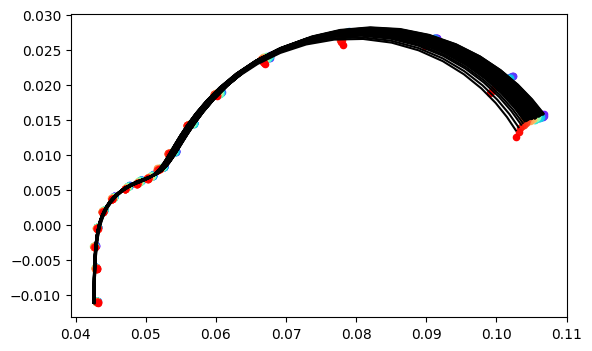

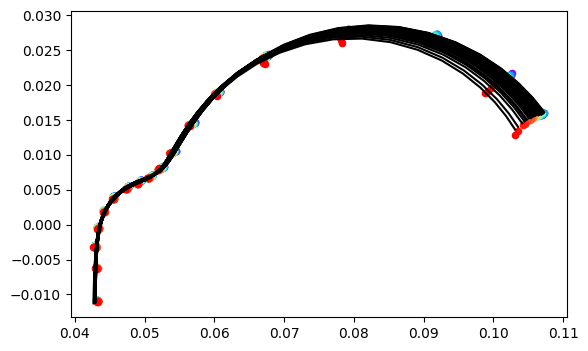

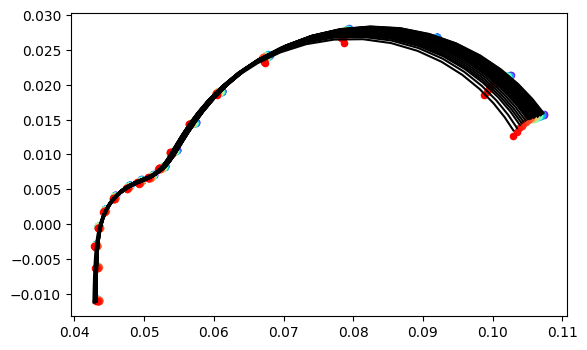

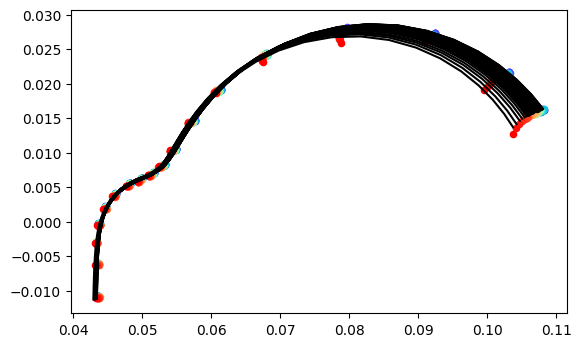

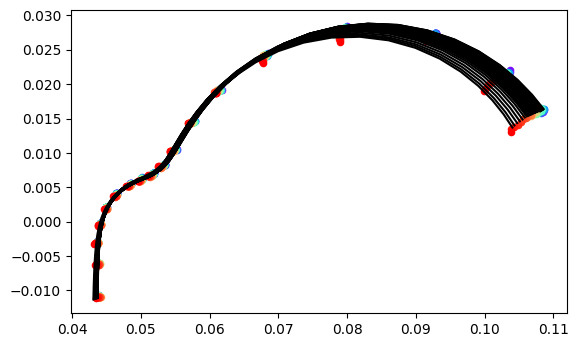

In [202]:
params_all = []
for spectra in spectra_all:
    
    params = loop.spectra_fitting(list(reversed(spectra))[:-3],bounds = bounds, init = init,freq_lims = [1,29000])
    params_all.append(params)


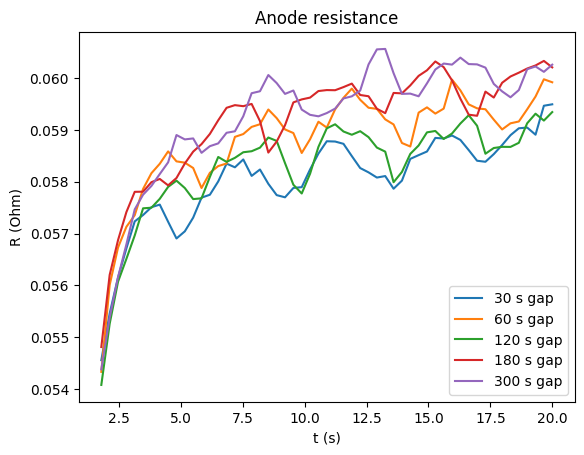

In [205]:
for params,label in zip(params_all,times):
    plt.plot(Times[5:],list(reversed(params[:,5]))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Anode resistance')
    plt.legend()


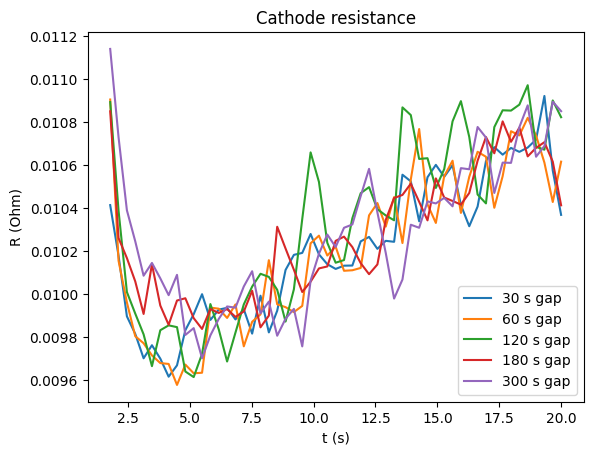

In [206]:
for params,label in zip(params_all,times):
    plt.plot(Times[5:],list(reversed(params[:,2]))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Cathode resistance')
    plt.legend()


ValueError: x and y must have same first dimension, but have shapes (56,) and (55,)

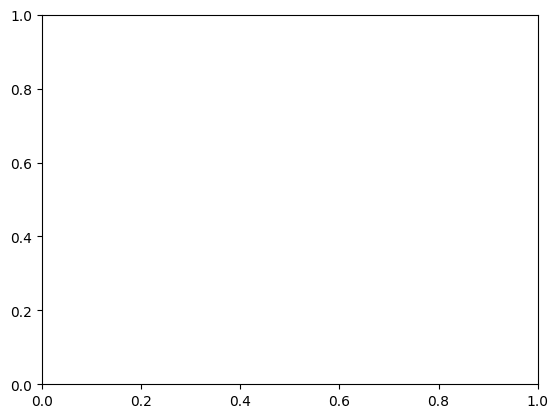

In [207]:
for params,label in zip(params_all,times):
    plt.plot(Times[4:],list(reversed(params[:,0]))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Ohmic resistance')
    plt.legend()


ValueError: x and y must have same first dimension, but have shapes (56,) and (55,)

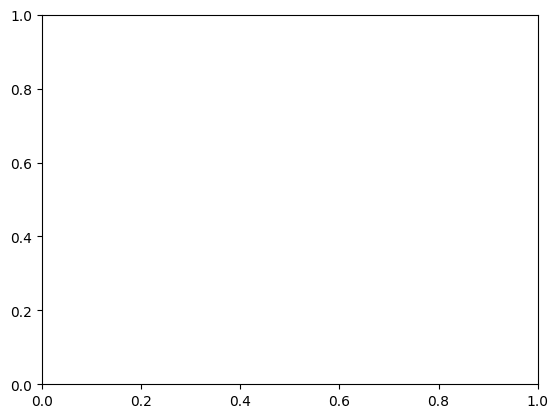

In [208]:
for params,label in zip(params_all,times):
    Cc = (params[:,2]*params[:,3]**(1-params[:,4]))**(1/params[:,4])
    plt.plot(Times[4:],list(reversed(Cc))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Cathode capacitance')
    plt.legend()

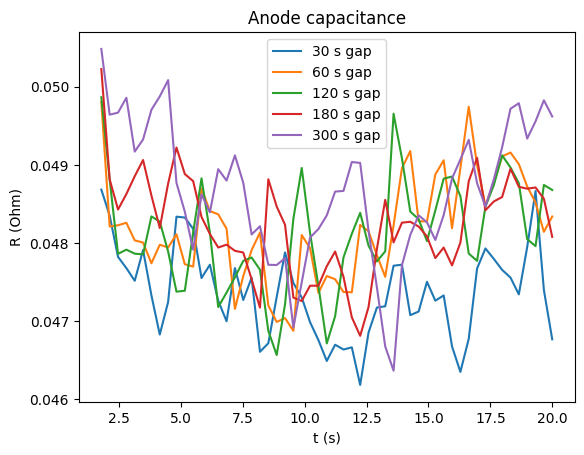

In [209]:
for params,label in zip(params_all,times):
    Ca = (params[:,5]*params[:,6]**(1-params[:,7]))**(1/params[:,7])
    plt.plot(Times[5:],list(reversed(Ca))[1:],label = str(label)+' s gap')
    plt.xlabel('t (s)')
    plt.ylabel('R (Ohm)')
    plt.title('Anode capacitance')
    plt.legend()

In [210]:
Is = []
for spectra in spectra_all:
    I = []
    for spectrum in spectra:
        i = np.mean(spectrum[2])
        I.append(i)
    Is.append(I)


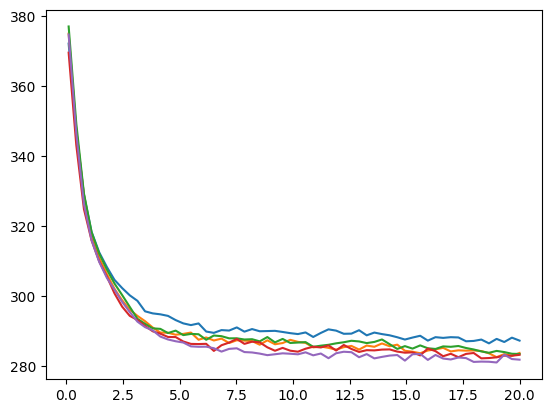

In [211]:
for I in Is:
    plt.plot(Times,I)

# 1,40 V

In [240]:
times = [30,60,120,180,300]
times = [60]
files = []
for time in times:
    files.append( glob(os.path.join(r'\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\new_open_cell/','*42*'+'*PEIS_C01.mpt')))
    print(files)
    # "\\ELECTROLYZER\PEM-WE_measurements\2026\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\new station\Loopeis new\new\L_02_Loopeis 1,40V_2_PEIS from 65kHz to 10kHz_03_PEIS_C01.mpt"

[['\\\\ELECTROLYZER\\PEM-WE_measurements\\2026\\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\\new station\\Loopeis new\\new_open_cell\\air_07_Loopeis 1,42V_2_PEIS from 65kHz to 10kHz_03_PEIS_C01.mpt', '\\\\ELECTROLYZER\\PEM-WE_measurements\\2026\\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\\new station\\Loopeis new\\new_open_cell\\air_07_Loopeis 1,42V_2_PEIS from 65kHz to 10kHz_07_PEIS_C01.mpt', '\\\\ELECTROLYZER\\PEM-WE_measurements\\2026\\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\\new station\\Loopeis new\\new_open_cell\\air_07_Loopeis 1,42V_2_PEIS from 65kHz to 10kHz_11_PEIS_C01.mpt', '\\\\ELECTROLYZER\\PEM-WE_measurements\\2026\\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\\new station\\Loopeis new\\new_open_cell\\air_07_Loopeis 1,42V_2_PEIS from 65kHz to 10kHz_15_PEIS_C01.mpt', '\\\\ELECTROLYZER\\PEM-WE_measurements\\2026\\372_IV_IV IrOx, 5 min Pt, 30 min C, etched cathode\\new station\\Loopeis new\\new_open_cell\\air_07_Loopeis 1,42V_2_PEIS from 65kHz 

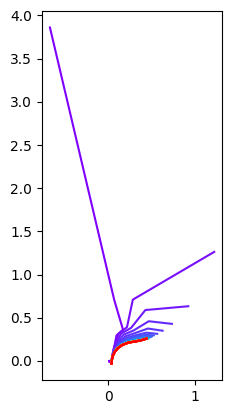

60 s done


In [242]:
spectra_all = []

time_start = 0.2
time_end = 30
points = 60
Times = np.linspace(time_start,time_end,points)
for time,file in zip(times,files):
    spectra= loop.spectra_calculation(list(reversed(file)),1.48, time_start,time_end,points, plot = True,control = 'Ref')
    
    spectra_all.append(spectra)
    print(str(time)+' s done')

(0.0, 1.0)

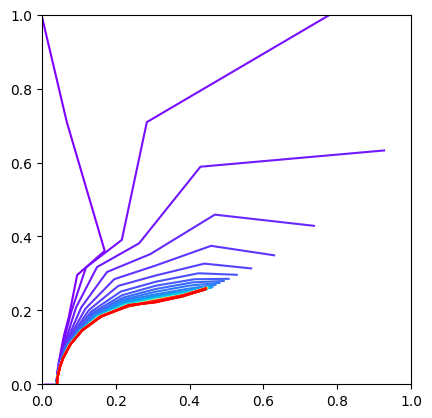

In [250]:
colors = we.get_colors(len(spectra_all[0]))
for spectrum,color in zip(spectra_all[0],colors):
    Z = spectrum[1]
    plt.plot(Z.real,-Z.imag,c=color)
plt.gca().set_aspect('equal')
plt.ylim(0,1)
plt.xlim(0,1)

In [ ]:
cir = 'R0-L0-p(R1,CPE1)-p(R2,CPE2)'
init = [0.02,1e-8,0.01,0.01,0.8,0.5,0.1,0.8]
bounds = ([0.001,1e-8,0.00001,0.0001,0.6,0.0001,0.001,0.6],[0.5,1e-5,1,1,1,100,1,1])

In [ ]:
params_all = []
for spectra in spectra_all:
    
    params = loop.spectra_fitting(list(reversed(spectra))[:-2],bounds = bounds, init = init,freq_lims = [1,29000])
    params_all.append(params)


In [243]:
Is = []
for spectra in spectra_all:
    I = []
    for spectrum in spectra:
        i = np.mean(spectrum[2])
        I.append(i)
    Is.append(I)


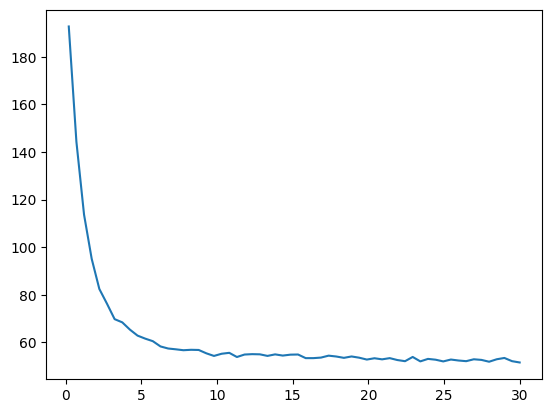

In [244]:
for I in Is:
    plt.plot(Times,I)

# 372 other

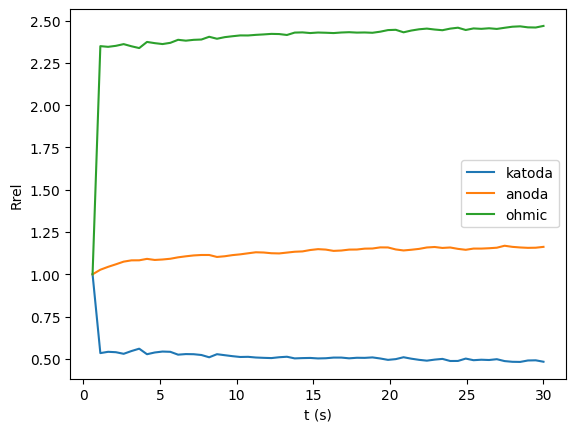

In [63]:

plt.plot(Times[1:],params_klasik[:,2]/params_klasik[:,2][0],label = 'katoda')
plt.plot(Times[1:],params_klasik[:,5]/params_klasik[:,5][0],label = 'anoda')
plt.plot(Times[1:],params_klasik[:,0]/params_klasik[:,0][0],label = 'ohmic')
plt.xlabel('t (s)')
plt.ylabel('Rrel')
plt.legend()


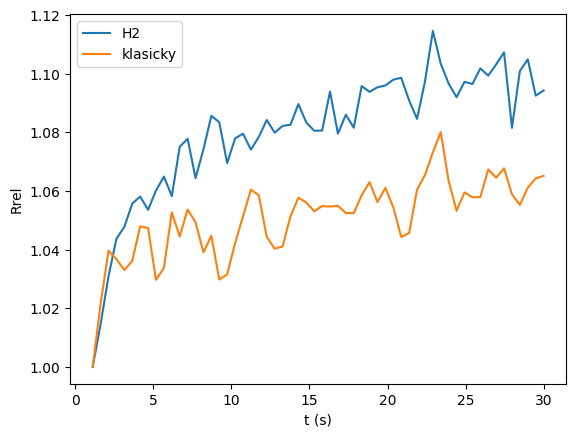

In [72]:
plt.plot(Times[2:],params_H2[:,5][1:]/params_H2[:,5][1],label = 'H2')
# plt.plot(params_H2[:,2]/params_H2[:,2][1])
# plt.plot(params_H2[:,0]/params_H2[:,0][1])
plt.plot(Times[2:],params_klasik[:,5][1:]/params_klasik[:,5][1],label = 'klasicky')
# plt.plot(params_klasik[:,2]/params_klasik[:,2][1])
# plt.plot(params_klasik[:,0]/params_klasik[:,0][1])
plt.xlabel('t (s)')
plt.ylabel('Rrel')
plt.legend()

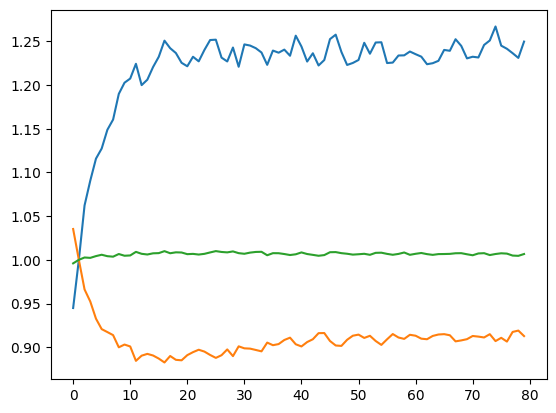

In [13]:
plt.plot(Times[1:],params_all[:,5]/params_all[:,5][1])
plt.plot(params_all[:,2]/params_all[:,2][1])
plt.plot(params_all[:,0]/params_all[:,0][1])

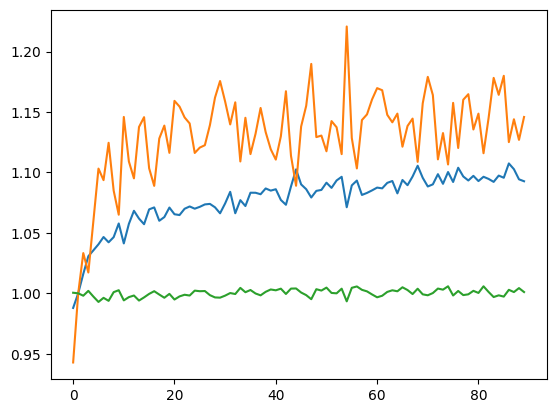

In [89]:
plt.plot(params_all[:,5]/params_all[:,5][1])
plt.plot(params_all[:,2]/params_all[:,2][1])
plt.plot(params_all[:,0]/params_all[:,0][1])

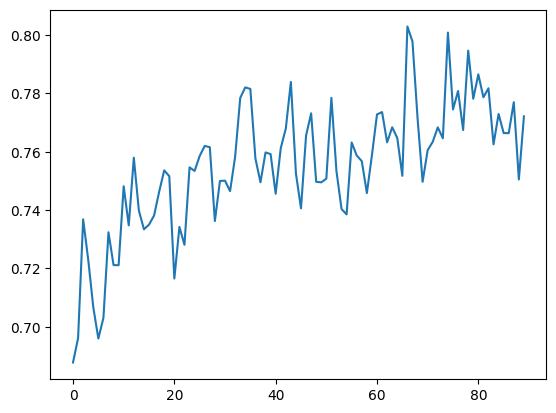

In [50]:
plt.plot(params_all[:,5])
# plt.plot(params_all[:,2])
# plt.plot(params_all[:,0])

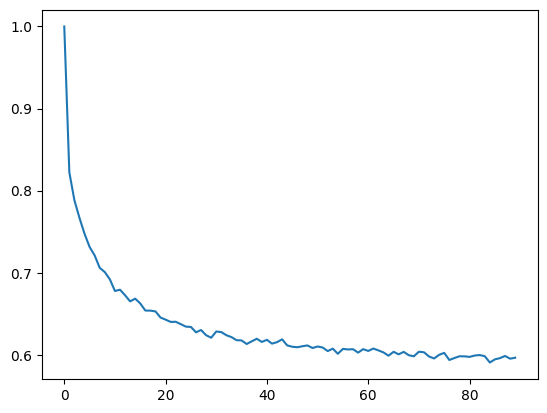

In [42]:
plt.plot(params_all[:,5]/params_all[:,5][0])
plt.plot(params_all[:,2]/params_all[:,2][0])
plt.plot(params_all[:,0]/params_all[:,0][0])

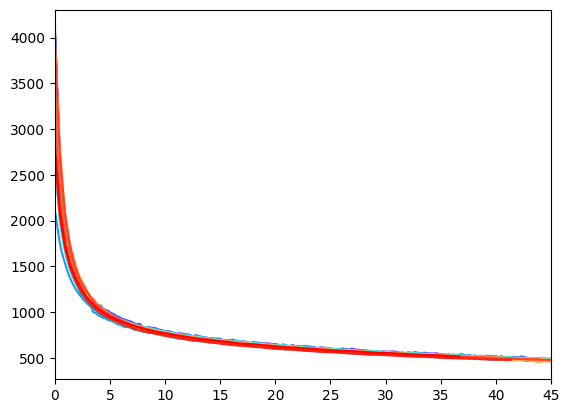

In [154]:
for files_x in files:
    cmap = plt.get_cmap('rainbow')
    colors = cmap(np.linspace(0,1,len(files_x)))
            
    for i,file in enumerate(files_x):
        # print(file)
        # header_lines = we.get_header_lines(file)
        
        try: 
            skip_rows = we.get_header_lines(file)
            with open(file,'r', encoding='latin1') as f:
                df = pd.read_csv(f,skiprows = skip_rows-1,delimiter = '\t')
    
    
            time = df['time/s']
            I = df['<I>/mA']
    
            # time = data[:,5]
            # time = data[:,7]
            # I = data[:,7]
            # I = data[:,10]
            plt.plot(time-time[0],I,c=colors[i])
        except:
            print('problem: '+file)
        plt.xlim(0,45)
        # plt.ylim(0,300)
    plt.show()


In [64]:
from hybdrt.models import DRT
from bayes_drt2.inversion import Inverter

\tag{2}

C:\Users\Herman\Python\PythonEnvs\py314_env\Lib\site-packages\bayes_drt2\inversion.py:678: UserWarning: Hyperparametric solution did not converge within 20 iterations
  warnings.warn(f'Hyperparametric solution did not converge within {max_iter} iterations')
13:33:49 - cmdstanpy - INFO - Chain [1] start processing
13:33:49 - cmdstanpy - INFO - Chain [1] done processing
13:33:49 - cmdstanpy - WARNING - The default behavior of CmdStanMLE.stan_variable() will change in a future release to always return a numpy.ndarray, even for scalar variables.
13:33:49 - cmdstanpy - WARNING - The default behavior of CmdStanMLE.stan_variable() will change in a future release to always return a numpy.ndarray, even for scalar variables.
13:33:49 - cmdstanpy - WARNING - The default behavior of CmdStanMLE.stan_variable() will change in a future release to always return a numpy.ndarray, even for scalar variables.
13:33:49 - cmdstanpy - WARNING - The default behavior of CmdStanMLE.stan_variable() will change in

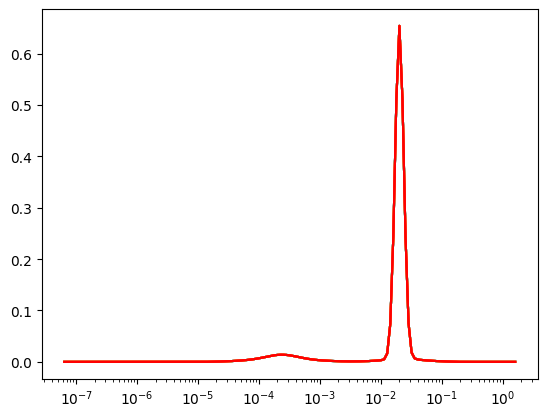

In [136]:
# drt = DRT()
inv_map = Inverter()
tau_plots = []
gammas = []
for spectra in spectra_all[1:2]:
    colors = we.get_colors(len(spectra))
    for spectrum,color in zip(spectra,colors):
        Z = spectrum[1][:-2]

        f = np.array(spectrum[0][:-2])
        # print(f)
        # drt.fit_eis(f, Z)

        inv_map.fit(f, Z, mode='optimize',nonneg = True,outliers = True,warmup=100, samples=100,init_from_ridge = True) 
        gamma_map = inv_map.final_gamma
        tau_plot_map = inv_map.tau_plot

        
        # tau_plot_hybrid = drt.get_tau_eval(20)
        # gamma_hybrid = drt.predict_drt(tau_plot_hybrid)
        tau_plots.append(tau_plot_map)
        gammas.append(gamma_map)
        plt.plot(tau_plot_hybrid,gamma_hybrid,c=color)
    plt.xscale('log')
    plt.show()

(0.0, 0.5)

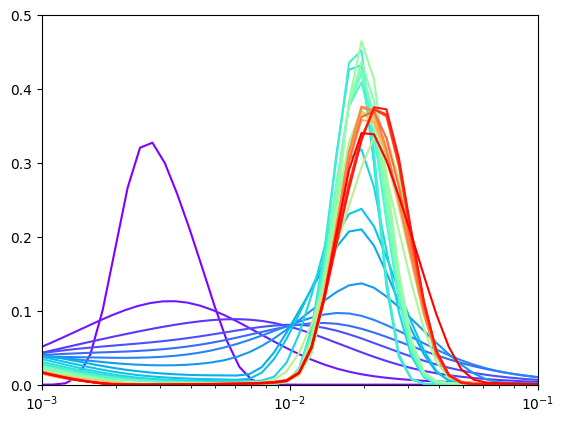

In [141]:
for tau,gamma,color in zip(tau_plots,gammas,colors):
    plt.plot(tau,gamma,c=color)
plt.xscale('log')
plt.xlim(1e-3,1e-1)
plt.ylim(0,0.5)
    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.88418


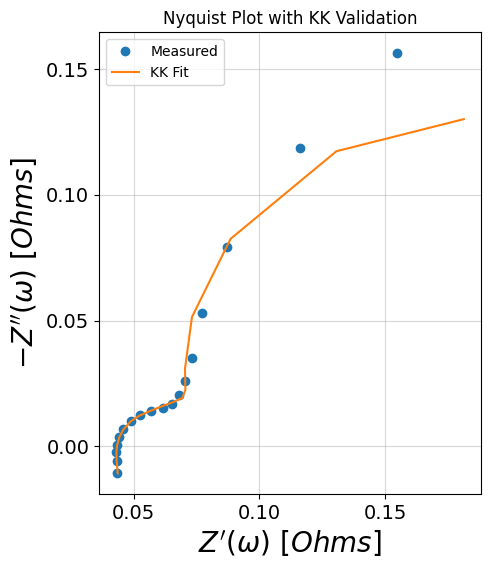

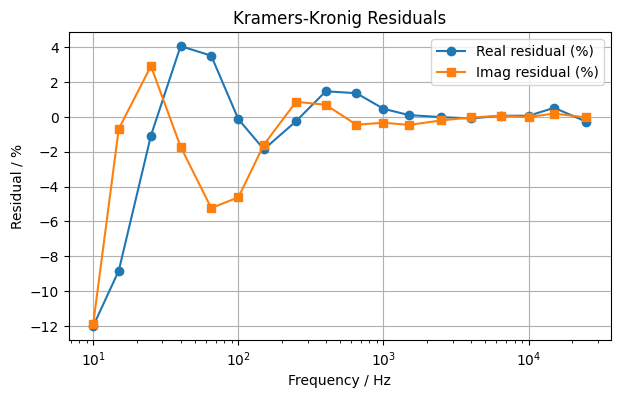

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.88342


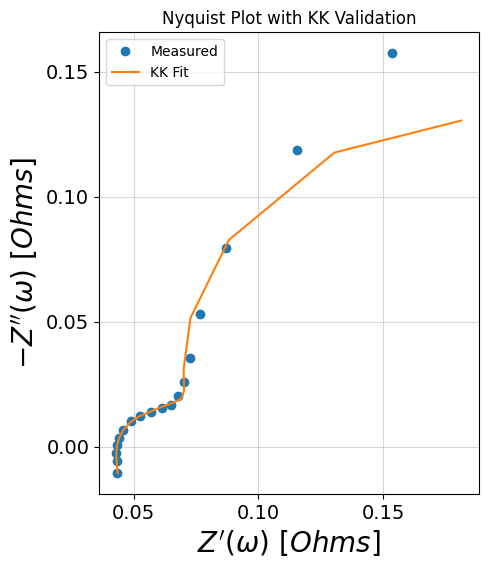

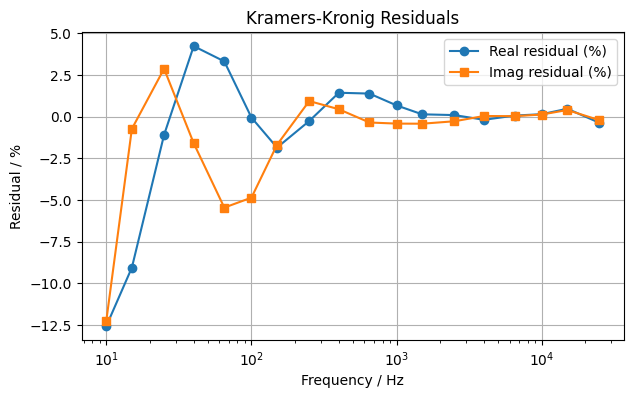

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.88165


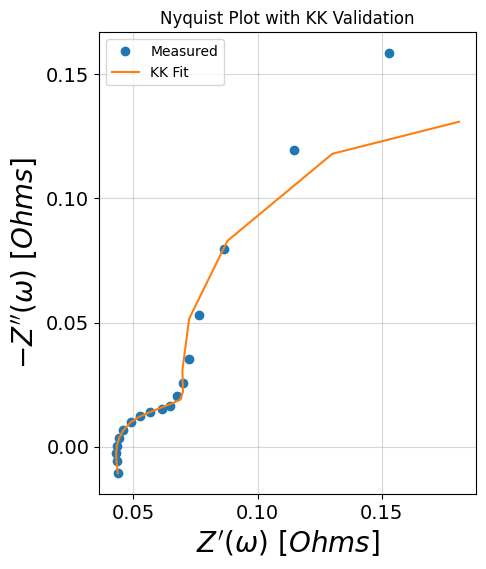

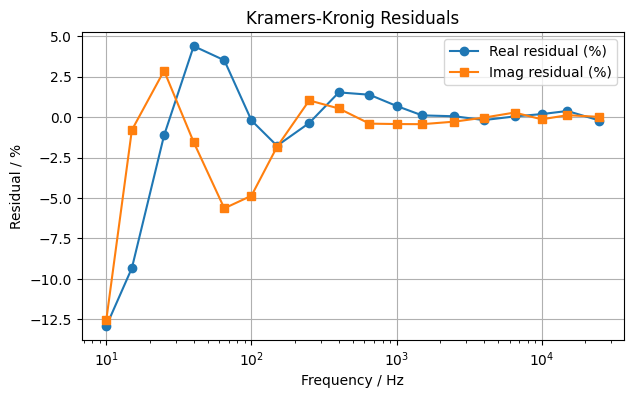

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.88193


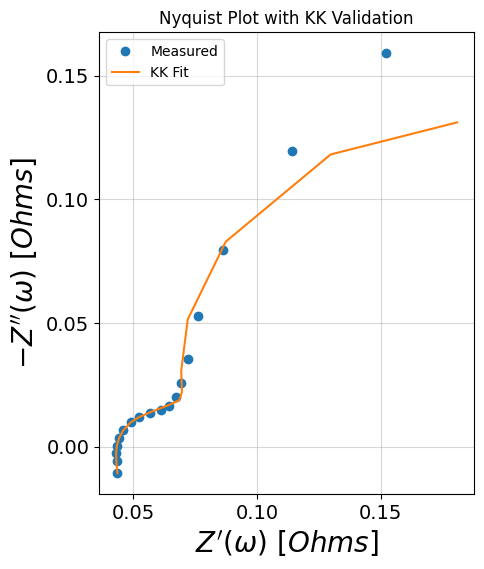

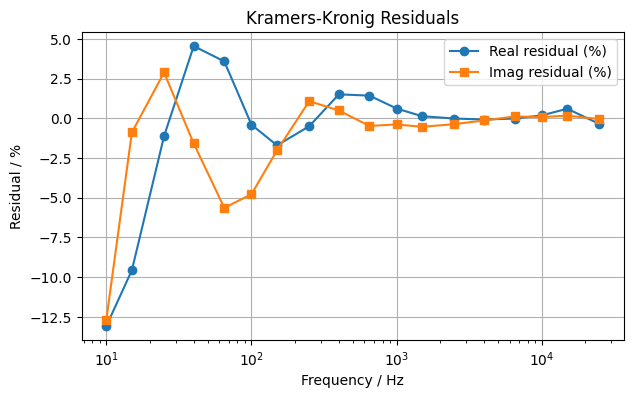

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.88073


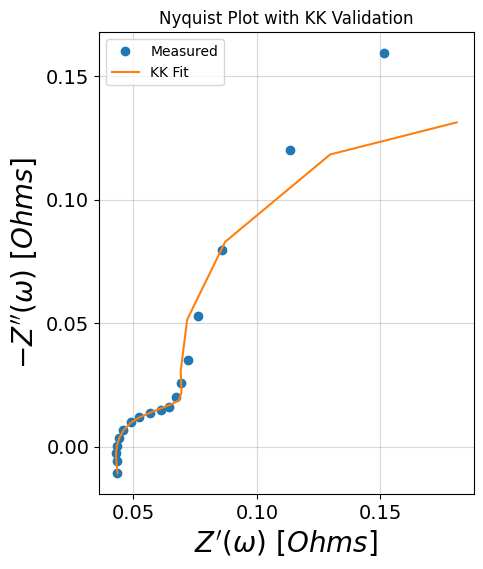

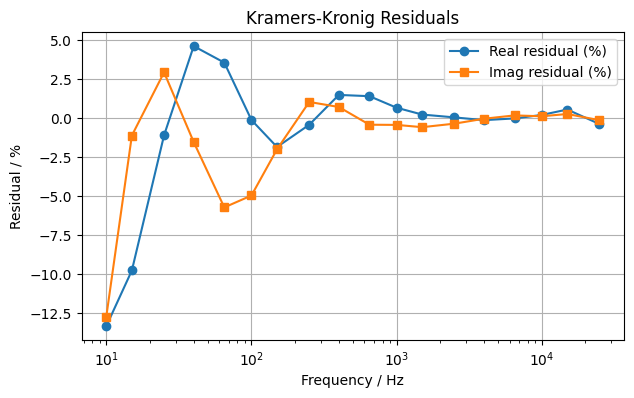

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.88066


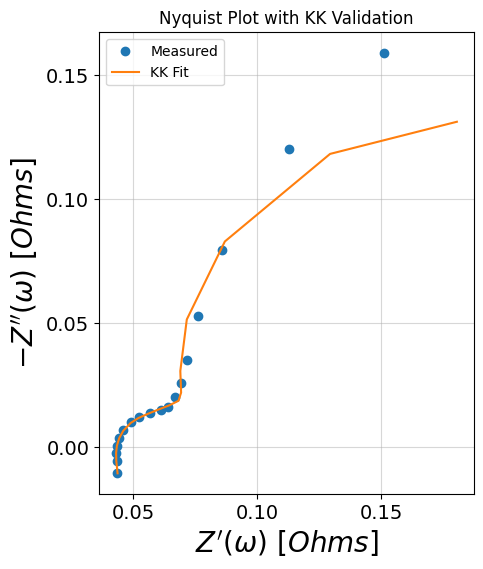

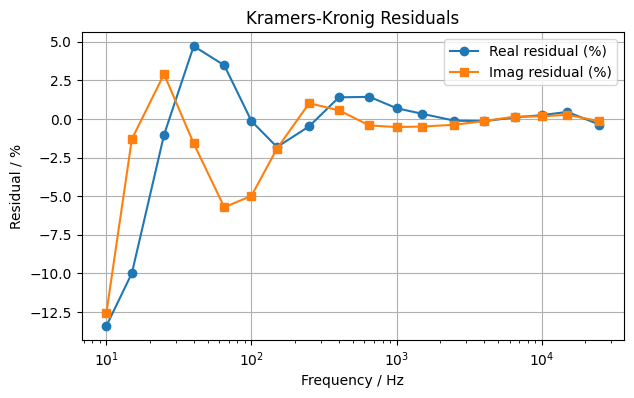

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.88083


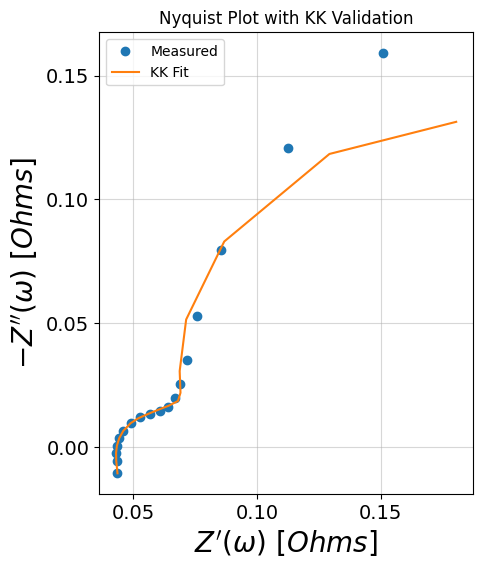

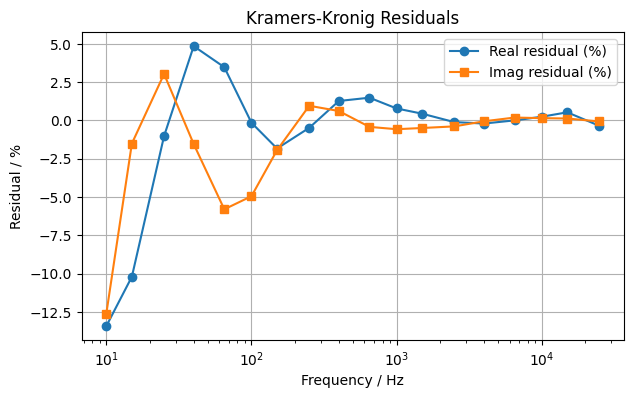

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.87971


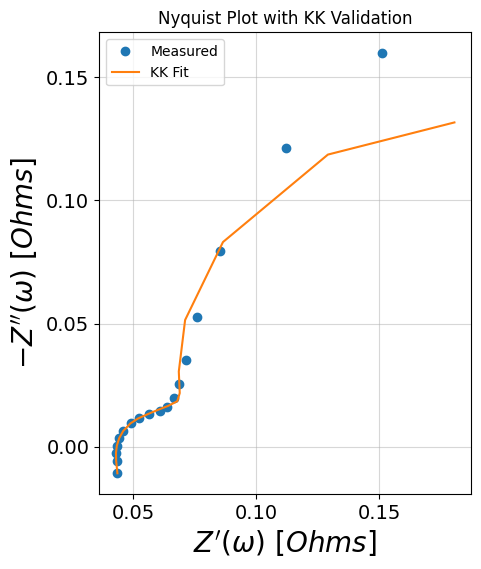

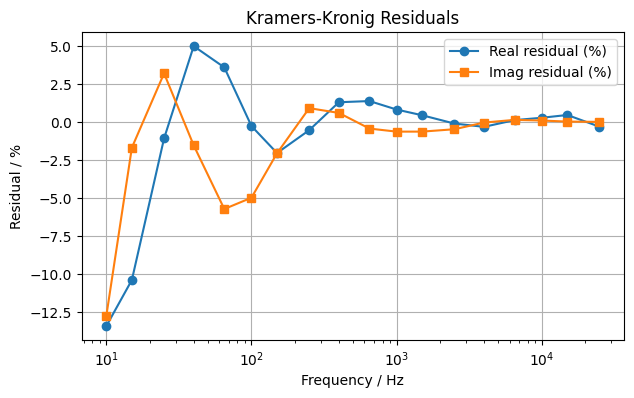

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.87841


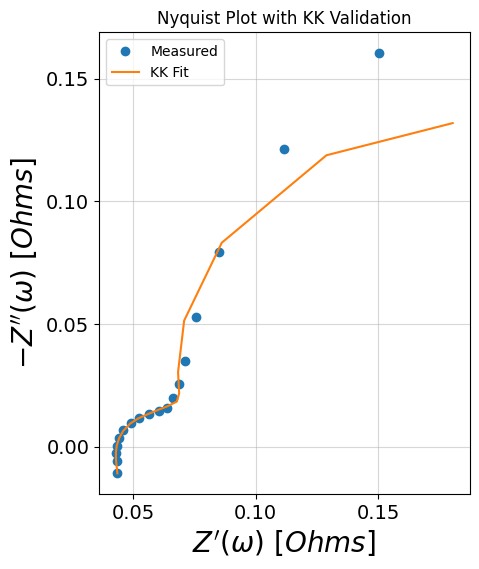

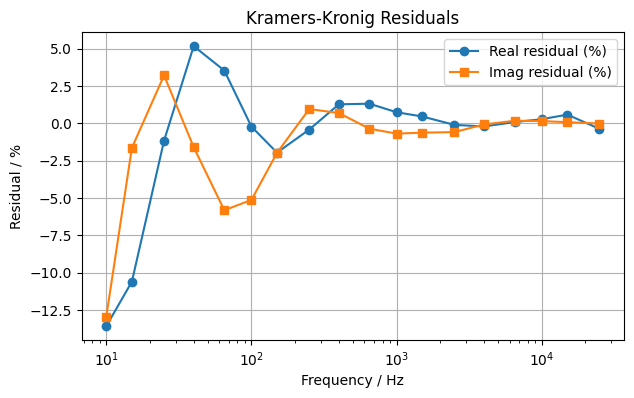

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.87959


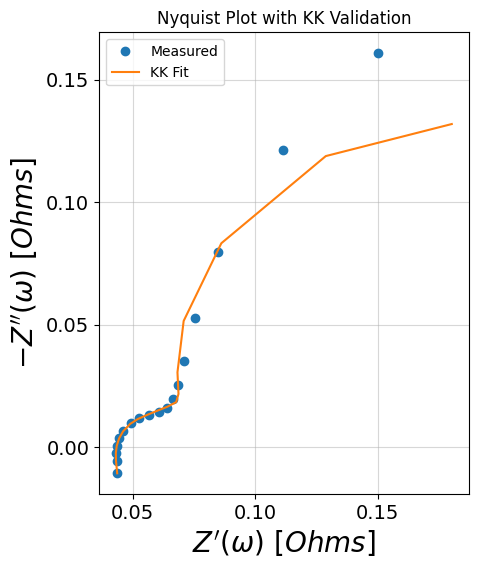

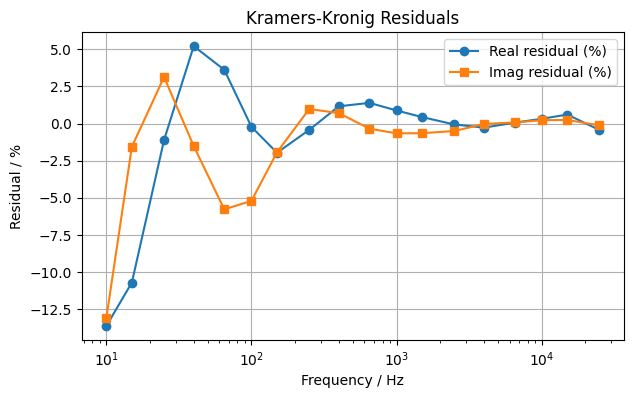

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.87942


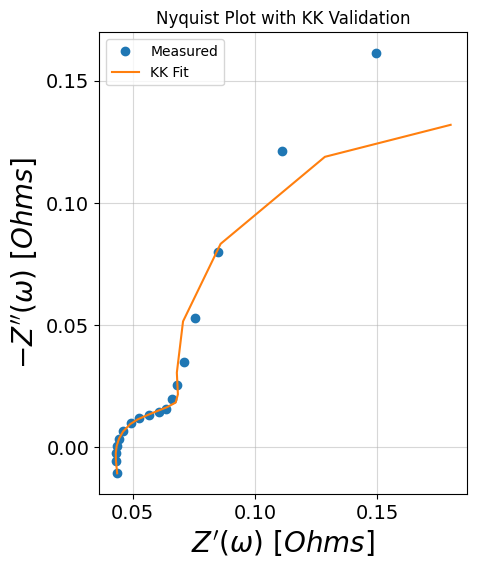

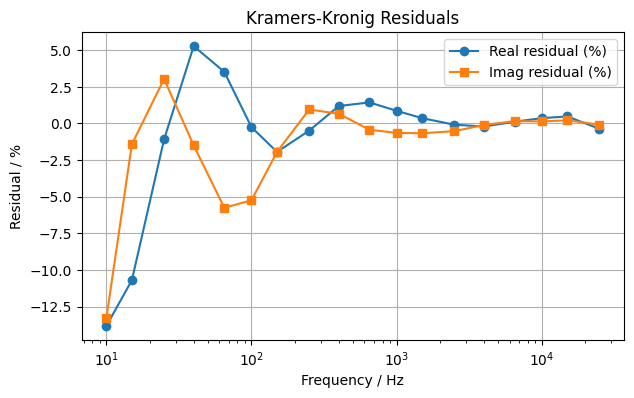

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.87835


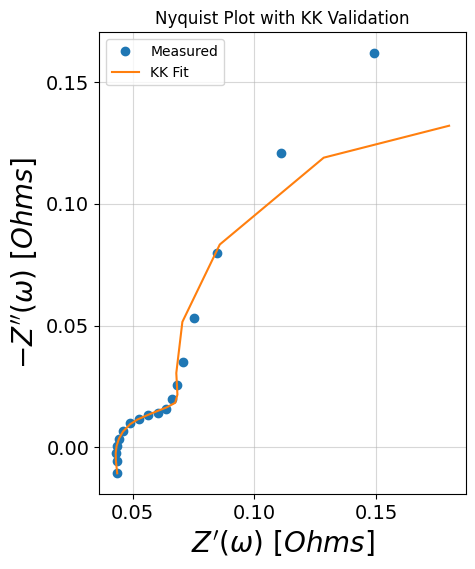

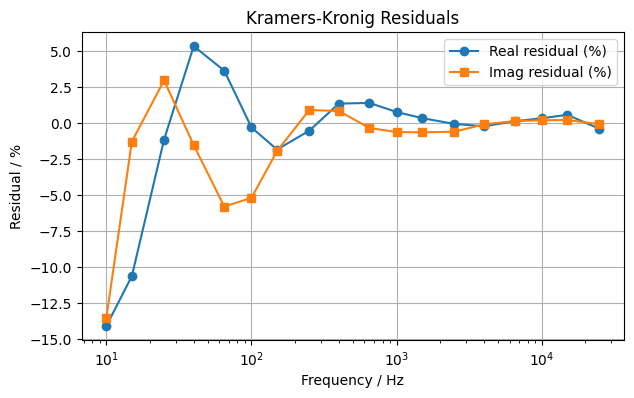

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.87827


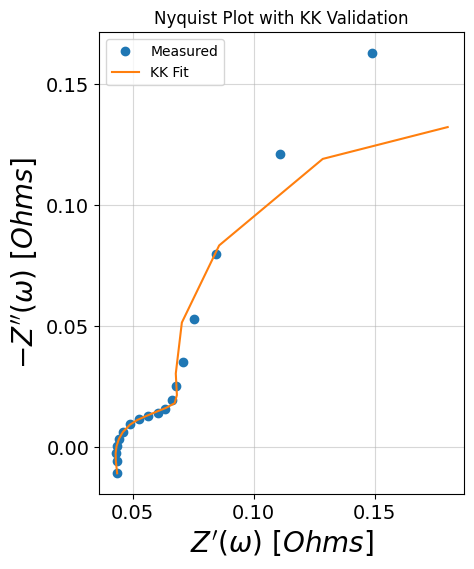

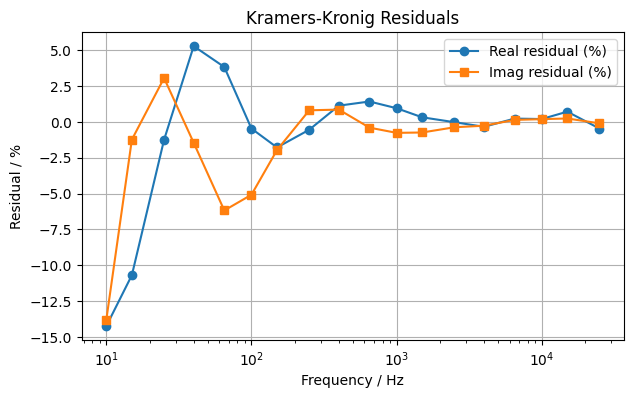

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.87786


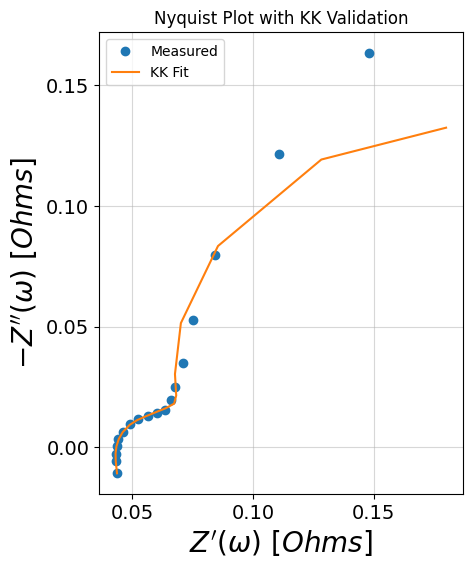

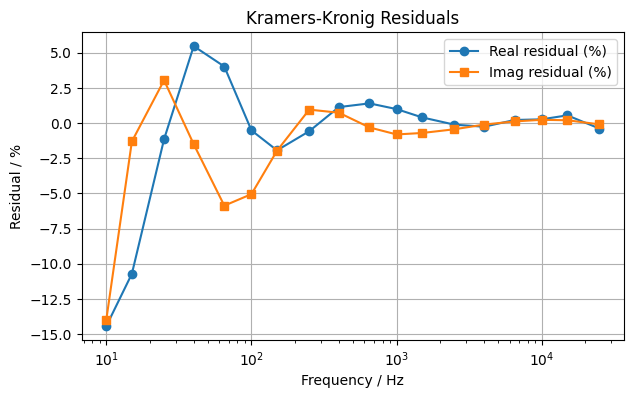

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.87694


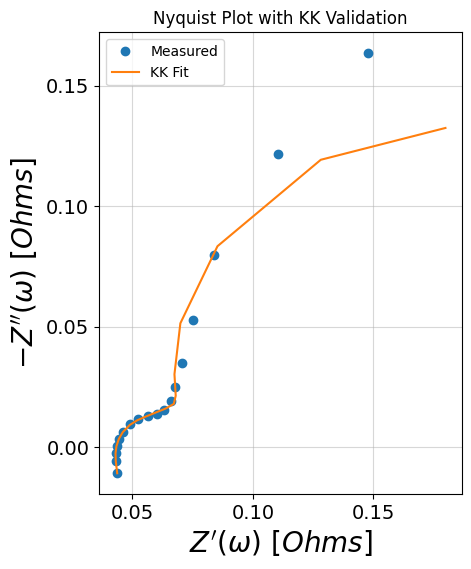

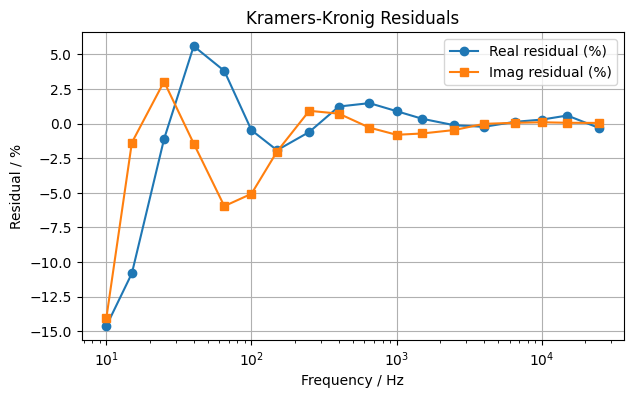

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.87789


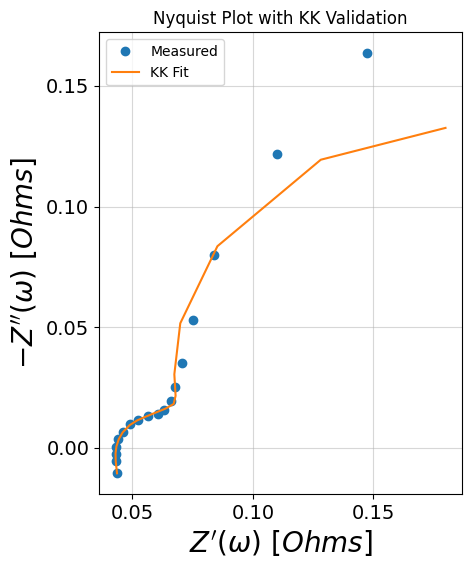

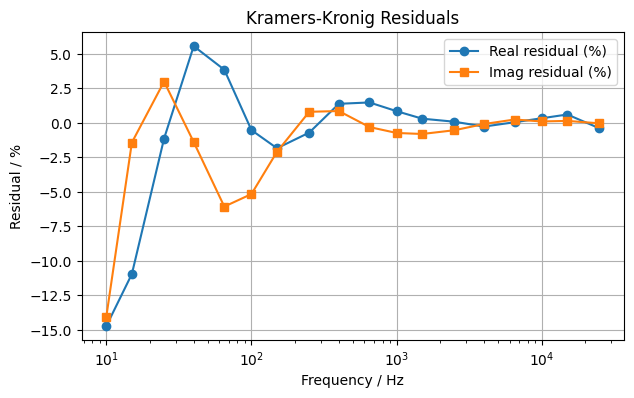

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.87728


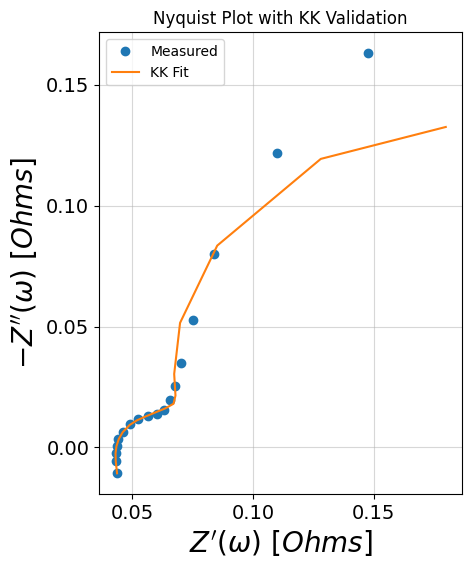

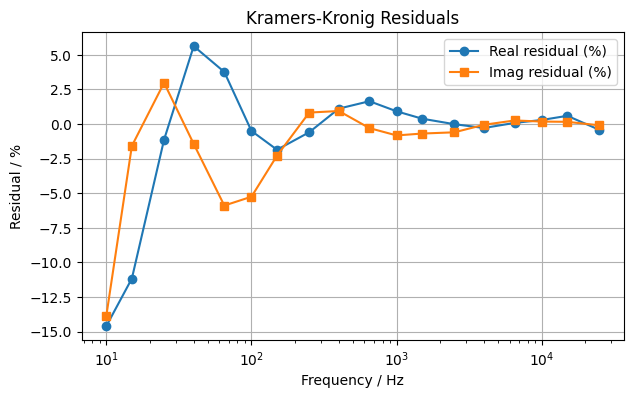

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.87694


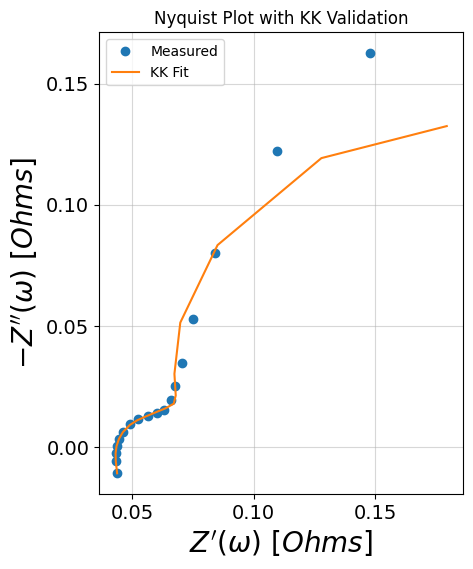

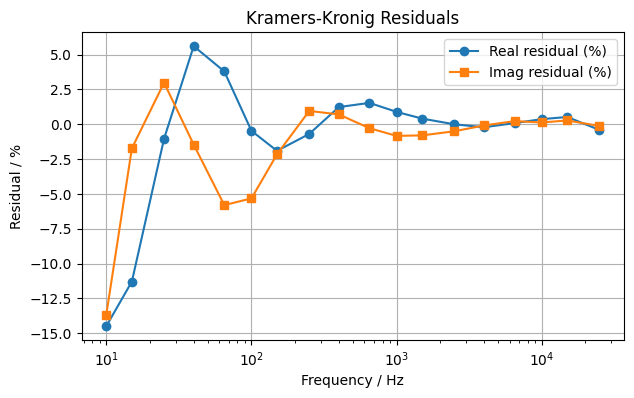

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.87769


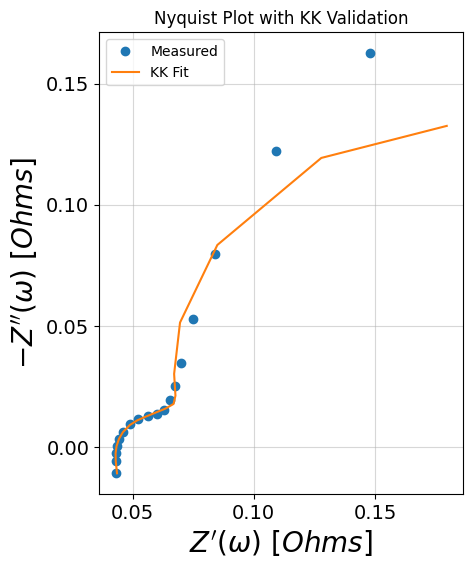

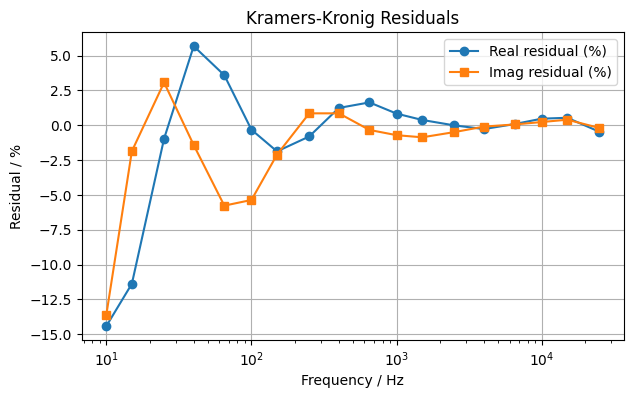

===== Kramers-Kronig Validation =====
Number of RC elements (M): 6
mu parameter: 0.87702


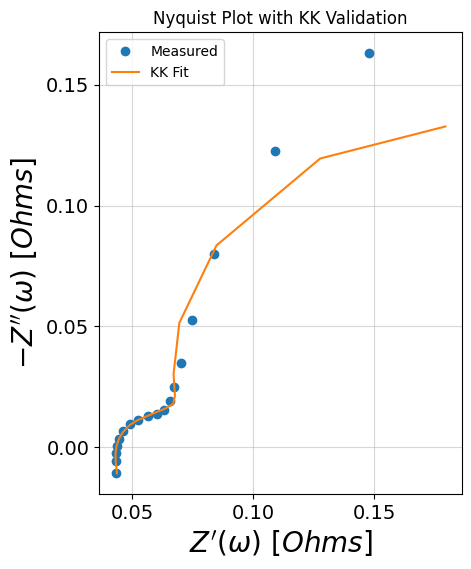

KeyboardInterrupt: 

In [130]:
import numpy as np
import matplotlib.pyplot as plt

from impedance.validation import linKK
from impedance.visualization import plot_nyquist
%load_ext autoreload
%autoreload 2
# -------------------------------------------------------------------
# INPUT:
# f  -> frequency array in Hz
# Z  -> complex impedance array
#
# Example:
# f = np.array([...])
# Z = np.array([...], dtype=complex)
# -------------------------------------------------------------------

# Example dummy data (replace with your own)
# f = np.logspace(5, -1, 60)

# # Example RC spectrum
# R = 10
# C = 1e-5
# omega = 2 * np.pi * f
# Z = R + 1 / (1j * omega * C)
for spectrum in spectra_all[1][5:]:
    Z = spectrum[1][:-2]
    f = np.array(spectrum[0][:-2])
    
    # -------------------------------------------------------------------
    # Kramers-Kronig validation using impedance.py
    # -------------------------------------------------------------------
    
    # linKK returns:
    # M          -> number of RC elements used
    # mu         -> under/over-fitting metric
    # Z_fit      -> KK-consistent fitted impedance
    # res_real   -> residuals (real)
    # res_imag   -> residuals (imag)
    M, mu, Z_fit, res_real, res_imag = linKK(
        f,
        Z,
        c=0.9,         # cutoff parameter
        max_M=15,       # maximum number of RC elements
        fit_type='complex'
    )
    
    print("===== Kramers-Kronig Validation =====")
    print(f"Number of RC elements (M): {M}")
    print(f"mu parameter: {mu:.5f}")
    
    # -------------------------------------------------------------------
    # Plot Nyquist comparison
    # -------------------------------------------------------------------
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    plot_nyquist(Z, ax=ax, fmt='o', label='Measured')
    plot_nyquist(Z_fit, ax=ax, fmt='-', label='KK Fit')
    
    ax.legend()
    ax.set_title("Nyquist Plot with KK Validation")
    
    plt.show()
    
    # -------------------------------------------------------------------
    # Plot residuals
    # -------------------------------------------------------------------
    
    fig, ax = plt.subplots(figsize=(7, 4))
    
    ax.semilogx(f, res_real * 100, 'o-', label='Real residual (%)')
    ax.semilogx(f, res_imag * 100, 's-', label='Imag residual (%)')
    
    ax.set_xlabel('Frequency / Hz')
    ax.set_ylabel('Residual / %')
    ax.set_title('Kramers-Kronig Residuals')
    ax.legend()
    ax.grid(True)
    
    plt.show()